# Rendu 1 – Exploration, Data Visualisation et Pre-processing

## Contexte du projet

Le **challenge Rakuten France Multimodal Product Data Classification** consiste à prédire la catégorie d'un produit e-commerce (`prdtypecode`) à partir de ses données textuelles et visuelles.

| | |
|---|---|
| **Entrées** | `designation` (titre), `description` (texte long), `image` (photo produit) |
| **Sortie** | `prdtypecode` - code entier représentant le type de produit |
| **Type de problème** | Classification multi-classe supervisée |
| **Modalités** | Texte + Image → approche **multimodale** |

## Objectifs de ce notebook (Rendu 1)

1. **Explorer** la structure du dataset : volumétrie, types de variables, valeurs manquantes  
2. **Analyser** la distribution de la variable cible et quantifier le déséquilibre entre classes  
3. **Investiguer** les données textuelles et visuelles avec visualisations + tests statistiques  
4. **Identifier** des relations entre variables explicatives et la cible  
5. **Appliquer** un pré-traitement NLP cohérent (pipeline unique, sans duplication)  
6. **Livrer** un dataset propre et documenté, prêt pour la modélisation (Rendu 2)


## 0. Imports et configuration

In [1]:
import os
import re
import zipfile
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal
import cv2


%matplotlib inline

warnings.filterwarnings("ignore")

try:
    import seaborn as sns
    sns.set_style("whitegrid")
    print("seaborn disponible.")
except ImportError:
    print("seaborn non disponible.")

try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    print("tqdm non disponible.")


seaborn disponible.


In [2]:
BASE_DIR = Path.cwd().resolve()
root_candidate = None
for parent in [BASE_DIR] + list(BASE_DIR.parents):
    if (parent / "data").is_dir():
        root_candidate = parent
        break

print(f"Répertoire racine trouvé : {BASE_DIR}")
print(f"Répertoire racine trouvé : {root_candidate}")

Répertoire racine trouvé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\notebooks
Répertoire racine trouvé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl


In [3]:
# configurer les roots (file location)

BASE_DIR = Path.cwd().resolve()
root_candidate = None
for parent in [BASE_DIR] + list(BASE_DIR.parents):
    if (parent / "data").is_dir():
        root_candidate = parent
        break

if root_candidate is None:
    #raise FileNotFoundError("Impossible de localiser le dossier data/.")
    pass


BASE_DIR = root_candidate

RAW_DIR       = BASE_DIR / "data" / "raw"
EXTRACTED_DIR = BASE_DIR / "data" / "extracted"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR   = BASE_DIR / "reports" / "figures"

for d in [PROCESSED_DIR, FIGURES_DIR, EXTRACTED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

X_TRAIN_FILE   = RAW_DIR / "X_train_update.csv"
X_TEST_FILE    = RAW_DIR / "X_test_update.csv"
Y_TRAIN_FILE   = RAW_DIR / "Y_train_CVw08PX.csv"
IMAGES_ZIP_FILE = RAW_DIR / "images.zip"

print("BASE_DIR     :", BASE_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURES_DIR  :", FIGURES_DIR)

BASE_DIR     : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl
PROCESSED_DIR: C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\processed
FIGURES_DIR  : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\reports\figures


In [4]:
# Librairie additionnel pour la détection des mots

try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem.snowball import FrenchStemmer
    nltk.download("stopwords", quiet=True)
    FRENCH_STOPWORDS = set(stopwords.words("french"))
    STEMMER = FrenchStemmer()
    print("NLTK disponible (stopwords + stemmer).")
except Exception as e:
    FRENCH_STOPWORDS = set()
    STEMMER = None
    print("NLTK non disponible :", e)

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 42
    LANGDETECT_AVAILABLE = True
    print("langdetect disponible.")
except Exception as e:
    LANGDETECT_AVAILABLE = False
    print("langdetect non disponible :", e)

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
    print("wordcloud disponible.")
except Exception as e:
    WORDCLOUD_AVAILABLE = False
    print("wordcloud non disponible :", e)

NLTK disponible (stopwords + stemmer).
langdetect disponible.
wordcloud disponible.


## 1. Fonctions utilitaires

In [5]:
def read_table(file_path: Path) -> pd.DataFrame:
    """Lire automatiquement un fichier csv ou excel."""
    suffix = file_path.suffix.lower()
    if suffix == ".csv":
        try:
            return pd.read_csv(file_path)
        except Exception:
            return pd.read_csv(file_path, sep=";")
    elif suffix in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)
    else:
        raise ValueError(f"Format non supporté : {file_path}")


def unzip_images(zip_path: Path, extract_to: Path) -> None:
    """Décompresser les images si nécessaire."""
    if not zip_path.exists():
        print(f"Zip introuvable : {zip_path}")
        return
    image_train_dir = extract_to / "image_train"
    image_test_dir  = extract_to / "image_test"
    if image_train_dir.exists() and image_test_dir.exists():
        print("Les images sont déjà extraites.")
        return
    print("Extraction des images en cours...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction terminée.")


def clean_text(text: str) -> str:
    """
    Pipeline de nettoyage textuel complète :
    1. Lowercasing
    2. Suppression des balises HTML
    3. Suppression des URLs
    4. Suppression des caractères spéciaux
    5. Suppression des stopwords français
    6. Stemming (FrenchStemmer : optionnel - dépend des langues détectées)
    7. Normalisation des espaces
    """
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    if FRENCH_STOPWORDS:
        tokens = [t for t in tokens if t not in FRENCH_STOPWORDS and len(t) > 1]
    if STEMMER is not None:
        tokens = [STEMMER.stem(t) for t in tokens]

    return " ".join(tokens)


def build_image_filename(imageid, productid) -> str:
    return f"image_{imageid}_product_{productid}.jpg"


def get_image_path(image_dir: Path, imageid, productid) -> Path:
    return image_dir / build_image_filename(imageid, productid)


def image_info(image_path: Path):
    """Retourne largeur, hauteur, mode couleur si l'image existe."""
    if not image_path.exists():
        return None, None, None
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode
        return width, height, mode
    except Exception:
        return None, None, None


def is_corrupted_image(image_path: Path) -> bool:
    if not image_path.exists():
        return True
    try:
        with Image.open(image_path) as img:
            img.verify()
        return False
    except Exception:
        return True


def outlier_ratio_iqr(series: pd.Series) -> dict:
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    ratio = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100
    return {"Q1": q1, "Q3": q3, "IQR": iqr,
            "lower": q1 - 1.5 * iqr, "upper": q3 + 1.5 * iqr,
            "outlier_%": round(ratio, 2)}


def get_top_tokens(series: pd.Series, n: int = 20) -> pd.DataFrame:
    all_words = " ".join(series.fillna("").astype(str)).split()
    return pd.DataFrame(Counter(all_words).most_common(n), columns=["token", "count"])


def detect_language_safe(text: str) -> str:
    text = str(text).strip()
    if not text:
        return "empty"
    if LANGDETECT_AVAILABLE:
        try:
            return detect(text)
        except Exception:
            return "unknown"
    return "unknown"


def save_fig(name: str) -> None:
    plt.savefig(FIGURES_DIR / name, dpi=200, bbox_inches="tight")
    plt.close()



def crop_image_borders(image_path, tol=15):
    """
    Recadre une image en ignorant les bordures unies
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = cv2.inRange(gray, tol, 255 - tol)
    coords = cv2.findNonZero(mask)
    
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        
        cropped_img = img[y:y+h, x:x+w]
        return cropped_img
    else:
        return img



def remove_custom_stopwords(text):
    if not isinstance(text, str):
        return text
    return " ".join([word for word in text.split() if word not in words_to_remove_set])



print("Fonctions utilitaires chargées.")

Fonctions utilitaires chargées.


## 2. Chargement des données

In [6]:
X_train = read_table(X_TRAIN_FILE)
X_test  = read_table(X_TEST_FILE)
Y_train = read_table(Y_TRAIN_FILE)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)

print("\nColonnes X_train :", list(X_train.columns))
print("Colonnes Y_train :", list(Y_train.columns))

X_train shape: (84916, 5)
X_test  shape: (13812, 5)
Y_train shape: (84916, 2)

Colonnes X_train : ['Unnamed: 0', 'designation', 'description', 'productid', 'imageid']
Colonnes Y_train : ['Unnamed: 0', 'prdtypecode']


In [7]:
# Les images sont déjà extraites dans data/raw
IMAGE_TRAIN_DIR = RAW_DIR / "image_train"
IMAGE_TEST_DIR  = RAW_DIR / "image_test"

train_dir_exists = IMAGE_TRAIN_DIR.exists()
test_dir_exists  = IMAGE_TEST_DIR.exists()

print("IMAGE_TRAIN_DIR :", IMAGE_TRAIN_DIR)
print("IMAGE_TEST_DIR  :", IMAGE_TEST_DIR)
print("IMAGE_TRAIN_DIR existe ?", train_dir_exists)
print("IMAGE_TEST_DIR  existe ?", test_dir_exists)

if not train_dir_exists or not test_dir_exists:
    raise FileNotFoundError(
        "Dossier image introuvable. Vérifier IMAGE_TRAIN_DIR et IMAGE_TEST_DIR."
    )

n_train_images = sum(1 for _ in IMAGE_TRAIN_DIR.glob("*.jpg"))
n_test_images  = sum(1 for _ in IMAGE_TEST_DIR.glob("*.jpg"))
print("Nombre d'images train :", n_train_images)
print("Nombre d'images test  :", n_test_images)

first_row = X_train.iloc[0]
first_image_path = get_image_path(
    IMAGE_TRAIN_DIR, first_row["imageid"], first_row["productid"]
)
print("Première image construite :", first_image_path)
print("Première image trouvée    :", first_image_path.exists())

if not first_image_path.exists():
    raise FileNotFoundError(
        "La première image construite est introuvable. Vérifier imageid, productid et le format du nom de fichier."
    )

IMAGE_TRAIN_DIR : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\raw\image_train
IMAGE_TEST_DIR  : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\raw\image_test
IMAGE_TRAIN_DIR existe ? True
IMAGE_TEST_DIR  existe ? True
Nombre d'images train : 84916
Nombre d'images test  : 13812
Première image construite : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\raw\image_train\image_1263597046_product_3804725264.jpg
Première image trouvée    : True


In [8]:
# Fusion X_train + Y_train
possible_keys = ["Unnamed: 0", "id", "index"]
merge_key = next((k for k in possible_keys if k in X_train.columns and k in Y_train.columns), None)

if merge_key is not None:
    df_train = X_train.merge(Y_train, on=merge_key, how="left")
    print("Fusion sur la clé :", merge_key)
else:
    df_train = pd.concat([X_train.reset_index(drop=True), Y_train.reset_index(drop=True)], axis=1)
    print("Fusion par ordre des lignes (aucune clé commune).")

df_test = X_test.copy()

# Détection de la variable cible
target_col = next((c for c in ["prdtypecode", "product_type_code", "target"] if c in df_train.columns), None)
print("\nVariable cible :", target_col)
print("df_train shape :", df_train.shape)
print("df_test  shape :", df_test.shape)

Fusion sur la clé : Unnamed: 0

Variable cible : prdtypecode
df_train shape : (84916, 6)
df_test  shape : (13812, 5)


In [9]:
# Vérification de la correspondance des index X_train / Y_train
merge_ok = (X_train.index == Y_train.index).all() if hasattr(X_train.index, '__iter__') else "N/A"
print(f"Correspondance des index X/Y : {merge_ok}")
print(f"df_train shape après fusion  : {df_train.shape}")
print(f"df_test  shape               : {df_test.shape}")


Correspondance des index X/Y : True
df_train shape après fusion  : (84916, 6)
df_test  shape               : (13812, 5)


## 3. Vue générale du dataset

Avant toute analyse approfondie, nous décrivons la structure globale du jeu de données : volumétrie, types des variables et valeurs manquantes.

Le dataset est issu du **challenge Rakuten France** hébergé sur challengedata.ens.fr.

> **Note sur le périmètre du dataset :**  
> Le challenge original Rakuten France porte sur ~99 000 produits répartis en **1 000+ catégories**.  
> Le sous-ensemble mis à disposition dans le cadre de ce projet de formation contient **84 916 observations d'entraînement** regroupées en **27 classes** (`prdtypecode`).  
> Toutes les analyses et décisions de modélisation de ce notebook sont effectuées sur ce sous-ensemble de 27 classes.

Il se compose de trois fichiers :
- `X_train_update.csv` : features d'entraînement (désignation, description, identifiants produit/image)
- `Y_train_CVw08PX.csv` : labels d'entraînement (code type produit)
- `X_test_update.csv` : features de test (sans labels)


In [10]:
# Tableau de volumétrie
overview = pd.DataFrame({
    "dataset":   ["X_train", "Y_train", "X_test"],
    "n_lignes":  [X_train.shape[0], Y_train.shape[0], X_test.shape[0]],
    "n_colonnes":[X_train.shape[1], Y_train.shape[1], X_test.shape[1]]
})
display(overview)

print("\nTypes des variables (df_train) :")
display(df_train.dtypes.to_frame("dtype"))

,dataset,n_lignes,n_colonnes
0,X_train,84916,5
1,Y_train,84916,2
2,X_test,13812,5



Types des variables (df_train) :


,dtype
Unnamed: 0,int64
designation,object
description,object
productid,int64
imageid,int64
prdtypecode,int64


,n_manquants,pct_%
description,29800,35.09


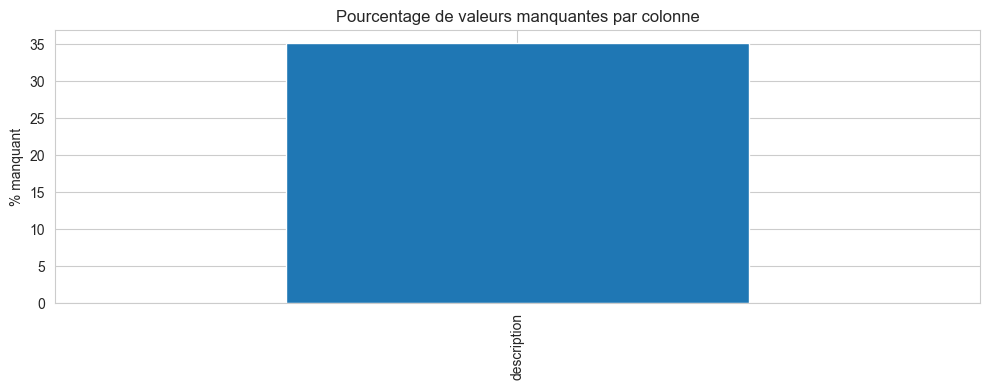

In [11]:
# Valeurs manquantes
missing = df_train.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df_train) * 100).round(2)

missing_df = pd.DataFrame({"n_manquants": missing, "pct_%": missing_pct})
display(missing_df)

if len(missing_df) > 0:
    plt.figure(figsize=(10, 4))
    missing_pct.plot(kind="bar")
    plt.title("Pourcentage de valeurs manquantes par colonne")
    plt.ylabel("% manquant")
    plt.tight_layout()
    #save_fig("missing_values_ratio.png")
    plt.show()
else:
    print("Aucune valeur manquante détectée dans les colonnes brutes.")

### 3.2 Analyse des doublons et des désignations ambiguës

Au-delà des valeurs manquantes, nous vérifions la présence de doublons et investiguons
les **désignations identiques** entre produits - un cas particulièrement informatif
pour évaluer la nécessité d'une approche multimodale.


In [12]:
# Doublons globaux
nb_doublons       = df_train.duplicated().sum()
nb_dup_desig      = df_train["designation"].duplicated().sum()
nb_dup_productid  = df_train["productid"].duplicated().sum()

print(f"Lignes dupliquées (toutes colonnes) : {nb_doublons}")
print(f"Désignations dupliquées             : {nb_dup_desig}")
print(f"productid dupliqués                 : {nb_dup_productid}")


Lignes dupliquées (toutes colonnes) : 0
Désignations dupliquées             : 2651
productid dupliqués                 : 0


In [13]:
# Investigation des désignations dupliquées : même désignation → même classe ou pas ?
df_dup = df_train[df_train["designation"].duplicated(keep=False)].sort_values("designation")

print(f"Produits avec désignation dupliquée : {len(df_dup)}")
print(f"Désignations uniques concernées     : {df_dup['designation'].nunique()}")
print()

exemple = df_dup.groupby("designation")[target_col].nunique()
cas_meme_classe  = (exemple == 1).sum()
cas_classes_diff = (exemple > 1).sum()

print(f"Désignations identiques → même classe    : {cas_meme_classe}")
print(f"Désignations identiques → classes diff.  : {cas_classes_diff}")
print()

# Exemple concret de désignation ambiguë
if cas_classes_diff > 0:
    desig_amb = exemple[exemple > 1].index[0]
    print(f"Exemple de désignation ambiguë : '{desig_amb[:80]}'")
    cols_show = ["designation", "description", "productid", "imageid", target_col]
    cols_show = [c for c in cols_show if c in df_train.columns]
    display(df_dup[df_dup["designation"] == desig_amb][cols_show])


Produits avec désignation dupliquée : 4073
Désignations uniques concernées     : 1422

Désignations identiques → même classe    : 1277
Désignations identiques → classes diff.  : 145

Exemple de désignation ambiguë : '01:20 2.4ghz 2rm Radio Remote Control Off Road Rc Rtr Voiture De Course De Camio'


,designation,description,productid,imageid,prdtypecode
69681,01:20 2.4ghz 2rm Radio Remote Control Off Road...,01:20 2.4GHZ 2RM Radio Remote Control Off Road...,3976901220,1271293302,1280
43764,01:20 2.4ghz 2rm Radio Remote Control Off Road...,01:20 2.4GHZ 2RM Radio Remote Control Off Road...,4006488521,1275485726,1281


### Constat, Désignations dupliquées

Sur 84 916 produits, certains partagent une désignation identique avec au moins un autre produit.
Parmi les désignations dupliquées :
- La majorité pointent vers **la même classe** → doublons bénins (même produit, vendeurs différents)
- Un sous-ensemble pointe vers **des classes différentes** malgré un titre identique

Ce second cas constitue une **limite structurelle du texte seul** comme feature de classification :
pour ces produits, la désignation (et parfois la description) ne suffit pas à distinguer la catégorie.
**L'image devient alors la seule source d'information discriminante.**

> Ce constat fournit une **preuve empirique directe** de la nécessité de l'approche multimodale,
> indépendamment des taux de valeurs manquantes.


## 4. Analyse de la variable cible

La variable cible `prdtypecode` représente le code de type du produit. C'est un problème de **classification multi-classe** : le modèle doit prédire la bonne catégorie parmi **27 classes** à partir des données textuelles et visuelles.

Comprendre la distribution des classes avant d'explorer les features est essentiel : un déséquilibre marqué influencera directement les choix de modélisation (métriques, stratégie de split, gestion des classes minoritaires).


In [14]:
if target_col is not None:
    class_counts = df_train[target_col].value_counts().sort_values(ascending=False)

    imbalance_metrics = {
        "Nombre de classes":                    int(class_counts.shape[0]),
        "Effectif max (classe la + fréquente)": int(class_counts.max()),
        "Effectif min (classe la - fréquente)": int(class_counts.min()),
        "Ratio min/max":                        round(class_counts.min() / class_counts.max(), 6),
        "Effectif moyen par classe":            round(float(class_counts.mean()), 2),
        "Effectif médian par classe":           round(float(class_counts.median()), 2),
        "Écart-type":                           round(float(class_counts.std()), 2),
        "Coefficient de variation":             round(float(class_counts.std() / class_counts.mean()), 4),
        "Classes avec <= 5 obs":                int((class_counts <= 5).sum()),
        "Classes avec <= 10 obs":               int((class_counts <= 10).sum()),
        "Part des 10 classes les + fréq. (%)": round(float(class_counts.head(10).sum() / class_counts.sum() * 100), 2)
    }

    display(pd.DataFrame(imbalance_metrics.items(), columns=["Indicateur", "Valeur"]))

,Indicateur,Valeur
0,Nombre de classes,27.000000
1,Effectif max (classe la + fréquente),10209.000000
2,Effectif min (classe la - fréquente),764.000000
3,Ratio min/max,0.074836
4,Effectif moyen par classe,3145.040000
5,Effectif médian par classe,2671.000000
6,Écart-type,2103.250000
7,Coefficient de variation,0.668800
8,Classes avec <= 5 obs,0.000000
9,Classes avec <= 10 obs,0.000000


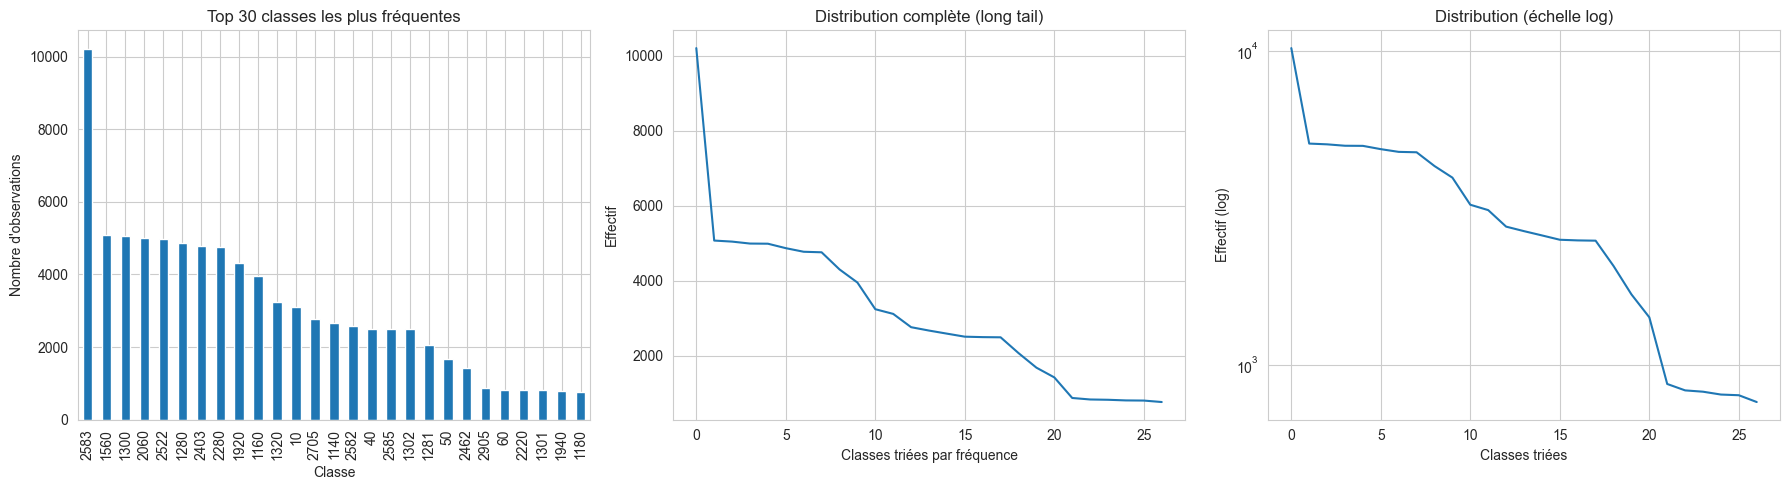

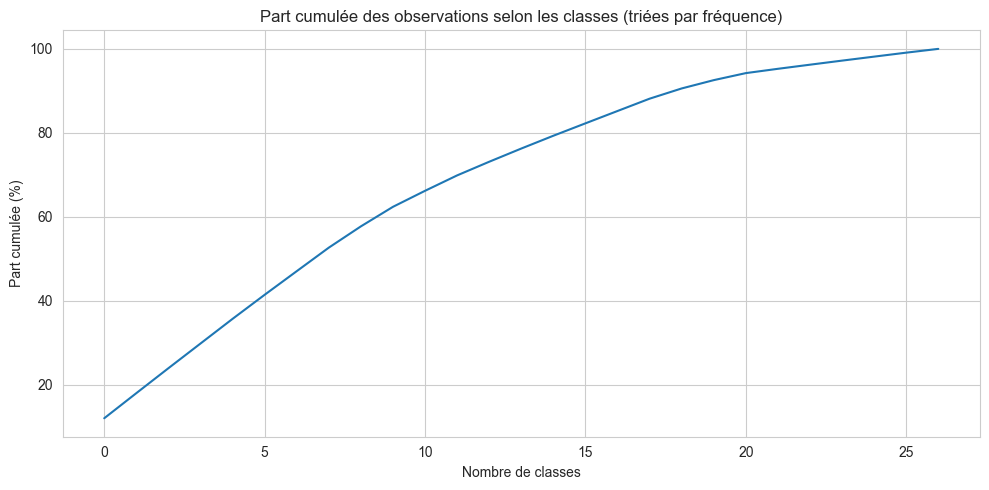

In [15]:
if target_col is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Top 30 classes
    class_counts.head(30).plot(kind="bar", ax=axes[0])
    axes[0].set_title("Top 30 classes les plus fréquentes")
    axes[0].set_xlabel("Classe")
    axes[0].set_ylabel("Nombre d'observations")

    # 2. Distribution complète (long tail)
    axes[1].plot(class_counts.values)
    axes[1].set_title("Distribution complète (long tail)")
    axes[1].set_xlabel("Classes triées par fréquence")
    axes[1].set_ylabel("Effectif")

    # 3. Échelle logarithmique
    axes[2].plot(class_counts.values)
    axes[2].set_yscale("log")
    axes[2].set_title("Distribution (échelle log)")
    axes[2].set_xlabel("Classes triées")
    axes[2].set_ylabel("Effectif (log)")

    plt.tight_layout()
    #save_fig("class_distribution.png")
    plt.show()

    # Courbe cumulative
    cumulative = class_counts.cumsum() / class_counts.sum() * 100
    plt.figure(figsize=(10, 5))
    plt.plot(cumulative.values)
    plt.title("Part cumulée des observations selon les classes (triées par fréquence)")
    plt.xlabel("Nombre de classes")
    plt.ylabel("Part cumulée (%)")
    plt.tight_layout()
    #save_fig("class_cumulative.png")
    plt.show()

### Interprétation

Le dataset contient **27 classes** réparties sur **84 916 observations** d'entraînement (moyenne : **3 145 obs./classe**). Les effectifs sont néanmoins très hétérogènes :

- La classe la plus fréquente compte **10 209 observations**, la moins fréquente **764**
- **Ratio min/max : 0,075**, la classe majoritaire est ~13× plus représentée que la minoritaire
- **Coefficient de variation : 0,67**, dispersion élevée des effectifs
- La médiane (2 671) est inférieure à la moyenne (3 145) : distribution asymétrique à droite
- Aucune classe avec moins de 10 observations : pas de classe "extrêmement rare"

> **Point positif :** avec seulement 27 classes et un minimum de 764 observations, le déséquilibre est **modéré** comparé à d'autres datasets de classification e-commerce. Il reste toutefois à gérer soigneusement.

---
### Key takeaways, Variable cible

- Dataset **déséquilibré mais gérable** (27 classes, ratio min/max : 0,075)
- Un **split stratifié** est indispensable pour préserver la distribution des classes en validation
- L'**accuracy** seule sera une métrique trompeuse : privilégier **macro-F1** et **weighted-F1**
- Les classes minoritaires devront faire l'objet d'une attention particulière en analyse d'erreurs
- L'usage de `class_weight='balanced'` ou de sur-échantillonnage ciblé sera évalué en Rendu 2


## 5. Analyse des données textuelles

Le dataset comporte deux variables textuelles :
- `designation` : titre court du produit, **toujours renseigné** (0 % de valeurs manquantes)
- `description` : texte long optionnel, **absent pour 35 % des produits**

Cette section analyse leur complétude et leur longueur, puis applique la pipeline NLP complète **en une seule étape** avant toutes les visualisations sémantiques.


In [16]:
text_cols = [c for c in ["designation", "description"] if c in df_train.columns]
print("Colonnes textuelles :", text_cols)

Colonnes textuelles : ['designation', 'description']


### 5.1 Complétude des variables textuelles

In [17]:
text_missing_summary = []
for col in text_cols:
    missing_count = df_train[col].isna().sum()
    empty_count   = (df_train[col].fillna("").astype(str).str.strip() == "").sum()
    text_missing_summary.append({
        "colonne":          col,
        "n_NaN":            missing_count,
        "% NaN":            round(missing_count / len(df_train) * 100, 2),
        "n_vides (NaN+'')":  empty_count,
        "% vides":          round(empty_count / len(df_train) * 100, 2)
    })

display(pd.DataFrame(text_missing_summary))

,colonne,n_NaN,% NaN,n_vides (NaN+''),% vides
0,designation,0,0.00,0,0.00
1,description,29800,35.09,29800,35.09


**Interprétation :** La `designation` est **toujours présente** (0 % de valeurs manquantes), c'est la variable textuelle la plus fiable. En revanche, **29 800 produits (35,09 %) n'ont pas de description**, ce qui signifie qu'ils ne peuvent être décrits que par leur titre court et leur image. Ce constat a deux implications directes :

1. La feature `has_description` (flag binaire) sera utile au modèle pour distinguer ces deux régimes
2. Une approche **multimodale** est indispensable : pour 35 % des produits, l'image est la seule source d'information riche


### 5.2 Statistiques de longueur (texte brut)

Avant tout nettoyage, nous mesurons la longueur des textes bruts pour comprendre la variabilité du contenu disponible et identifier d'éventuels textes trop courts ou trop longs.


In [18]:
for col in text_cols:
    df_train[f"{col}_length"]     = df_train[col].fillna("").astype(str).apply(len)
    df_test[f"{col}_length"]      = df_test[col].fillna("").astype(str).apply(len)
    df_train[f"{col}_word_count"] = df_train[col].fillna("").astype(str).apply(lambda x: len(x.split()))
    df_test[f"{col}_word_count"]  = df_test[col].fillna("").astype(str).apply(lambda x: len(x.split()))

if "designation_length" in df_train.columns and "description_length" in df_train.columns:
    df_train["text_total_length"]     = df_train["designation_length"]     + df_train["description_length"]
    df_test["text_total_length"]      = df_test["designation_length"]      + df_test["description_length"]
    df_train["text_total_word_count"] = df_train["designation_word_count"] + df_train["description_word_count"]
    df_test["text_total_word_count"]  = df_test["designation_word_count"]  + df_test["description_word_count"]

length_cols = [c for c in ["designation_length", "description_length",
                            "designation_word_count", "description_word_count",
                            "text_total_length", "text_total_word_count"] if c in df_train.columns]
display(df_train[length_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
designation_length,84916.0,70.163303,36.793383,11.0,43.0,64.0,90.0,250.0
description_length,84916.0,524.555926,754.893905,0.0,0.0,231.0,823.0,12451.0
designation_word_count,84916.0,11.557374,6.207966,3.0,7.0,11.0,14.0,56.0
description_word_count,84916.0,80.166635,115.411284,0.0,0.0,35.0,125.0,2068.0
text_total_length,84916.0,594.719228,762.067621,11.0,65.0,313.0,903.0,12535.0
text_total_word_count,84916.0,91.724010,116.318779,3.0,11.0,48.0,137.0,2078.0


In [19]:
# Détection d'outliers (IQR)
for col in ["designation_length", "description_length", "text_total_length"]:
    if col in df_train.columns:
        print(f"\n--- Outliers : {col} ---")
        display(pd.DataFrame([outlier_ratio_iqr(df_train[col])], index=[col]))


--- Outliers : designation_length ---


,Q1,Q3,IQR,lower,upper,outlier_%
designation_length,43.0,90.0,47.0,-27.5,160.5,2.42



--- Outliers : description_length ---


,Q1,Q3,IQR,lower,upper,outlier_%
description_length,0.0,823.0,823.0,-1234.5,2057.5,4.19



--- Outliers : text_total_length ---


,Q1,Q3,IQR,lower,upper,outlier_%
text_total_length,65.0,903.0,838.0,-1192.0,2160.0,4.08


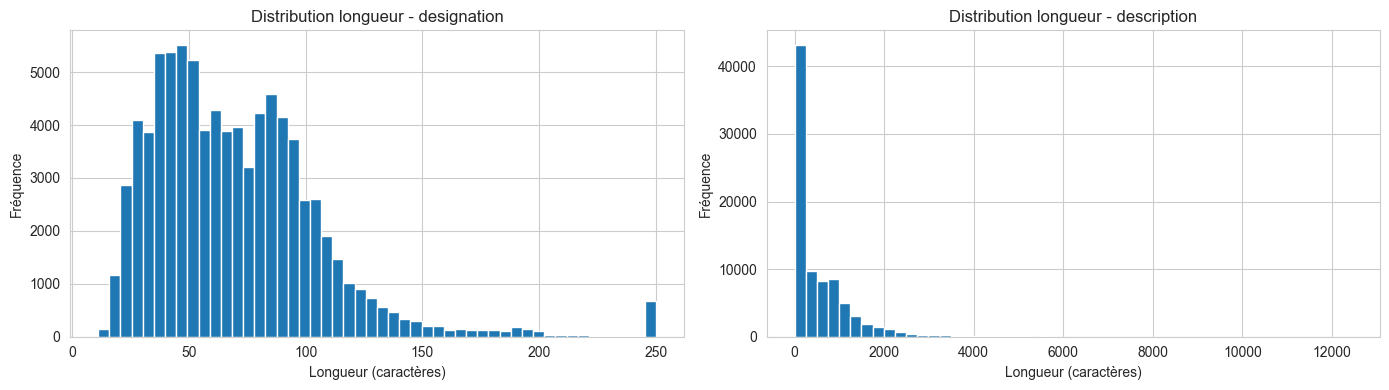

In [20]:
# Distributions
fig, axes = plt.subplots(1, len(text_cols), figsize=(7 * len(text_cols), 4))
if len(text_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, text_cols):
    df_train[f"{col}_length"].hist(bins=50, ax=ax)
    ax.set_title(f"Distribution longueur - {col}")
    ax.set_xlabel("Longueur (caractères)")
    ax.set_ylabel("Fréquence")

plt.tight_layout()
#save_fig("text_length_distribution.png")
plt.show()

**Interprétation :** Les deux variables présentent des distributions très asymétriques :

- `designation` : longueur moyenne **70 car.** (≈ 11,6 mots), relativement homogène, titre court standardisé. Taux d'outliers IQR : **2,42 %**
- `description` : longueur moyenne **524 car.** (≈ 80 mots) avec un écart-type de **754**, très variable. La médiane à 231 car. vs moyenne à 524 révèle des descriptions très longues qui tirent la moyenne. Taux d'outliers IQR : **4,19 %**

Ces constats justifient des stratégies de **troncature** (`max_length` dans les transformers) ou de **pondération** lors de la vectorisation. La longueur du texte sera conservée comme feature dérivée auxiliaire.


### 5.3 Pré-traitement NLP (pipeline unique)

Nous appliquons ici **une seule fois** la pipeline de nettoyage complète dans cet ordre :
1. **Lowercasing** : normalisation de la casse
2. **Suppression des balises HTML** : nettoyage des artifacts web
3. **Suppression des URLs** : élimination des liens non informatifs
4. **Suppression des caractères spéciaux** : conservation des lettres, chiffres et accents
5. **Suppression des stopwords français** (NLTK) : élimination des mots grammaticaux non discriminants
6. **Stemming** (FrenchStemmer) : réduction des mots à leur radical pour regrouper les formes fléchies

C'est cette version nettoyée (`_clean`) qui sera utilisée pour **toutes** les visualisations sémantiques suivantes et pour la modélisation.


In [21]:
for col in text_cols:
    df_train[f"{col}_clean"] = df_train[col].fillna("").astype(str).apply(clean_text)
    df_test[f"{col}_clean"]  = df_test[col].fillna("").astype(str).apply(clean_text)

# Concaténation des textes nettoyés
if "designation_clean" in df_train.columns and "description_clean" in df_train.columns:
    df_train["text_concat"] = (df_train["designation_clean"] + " " + df_train["description_clean"]).str.strip()
    df_test["text_concat"]  = (df_test["designation_clean"]  + " " + df_test["description_clean"]).str.strip()
elif "designation_clean" in df_train.columns:
    df_train["text_concat"] = df_train["designation_clean"]
    df_test["text_concat"]  = df_test["designation_clean"]

# Comparaison avant/après nettoyage
comparison = []
for col in text_cols:
    raw_wc   = df_train[f"{col}_word_count"].mean()
    clean_wc = df_train[f"{col}_clean"].apply(lambda x: len(x.split())).mean()
    comparison.append({
        "colonne":                col,
        "mots_moyen_brut":        round(raw_wc, 2),
        "mots_moyen_nettoyé":     round(clean_wc, 2),
        "réduction_%":            round((1 - clean_wc / raw_wc) * 100, 1) if raw_wc > 0 else None
    })

display(pd.DataFrame(comparison))
print("\nExemple de nettoyage :")
display(df_train[[text_cols[0], f"{text_cols[0]}_clean"]].head(3))

,colonne,mots_moyen_brut,mots_moyen_nettoyé,réduction_%
0,designation,11.56,9.24,20.0
1,description,80.17,55.80,30.4



Exemple de nettoyage :


,designation,designation_clean
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,olivi personalisiert notizbuch 150 seiten punk...
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,journal art 133 28 09 2001 art march salon art...
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,grand stylet ergonom bleu gamepad nintendo wii...


### 5.3b Comparaison avant / après nettoyage, exemples qualitatifs

Le tableau ci-dessous illustre l'effet concret de la pipeline sur quelques produits.


In [22]:
# Comparaison avant / après nettoyage : tableau qualitatif

sample_indices = []

# 1. produit sans description
no_desc = df_train[df_train["description"].isna()].index
if len(no_desc) > 0:
    sample_indices.append(no_desc[0])

# 2. produits avec description
with_desc = df_train[df_train["description"].notna()].index
for idx in with_desc[:6]:
    if idx not in sample_indices:
        sample_indices.append(idx)
    if len(sample_indices) == 5:
        break

rows = []
for idx in sample_indices:
    row = df_train.loc[idx]
    rows.append({
        "designation (brut)":        str(row["designation"])[:70] if pd.notna(row["designation"]) else "(absent)",
        "designation (nettoyée)":    str(row["designation_clean"])[:70] if "designation_clean" in df_train.columns else "-",
        "description (brut, 70 car)": str(row["description"])[:70] if pd.notna(row["description"]) else "(absent / NaN)",
        "description (nettoyée)":    str(row["description_clean"])[:70] if "description_clean" in df_train.columns else "-",
    })

comparison_df = pd.DataFrame(rows, index=[f"Ex. {i+1}" for i in range(len(rows))])

# Affichage transposé pour lisibilité
display(comparison_df.T)


,Ex. 1,Ex. 2,Ex. 3,Ex. 4,Ex. 5
designation (brut),Olivia: Personalisiertes Notizbuch / 150 Seite...,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,La Guerre Des Tuques,Conquérant Sept Cahier Couverture Polypro 240 ...,Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - ...
designation (nettoyée),olivi personalisiert notizbuch 150 seiten punk...,grand stylet ergonom bleu gamepad nintendo wii...,guerr tuqu,conquer sept cahi couvertur polypro 240 320 mm...,tent pli v3s5 pro pvc blanc 4m50 longueur 4m50...
"description (brut, 70 car)",(absent / NaN),PILOT STYLE Touch Pen de marque Speedlink est ...,Luc a des id&eacute;es de grandeur. Il veut or...,CONQUERANT CLASSIQUE Cahier 240 x 320 mm seyès...,Tente pliante V3S5 Pro PVC 500 gr/m² - 3 x 4m5...
description (nettoyée),,pilot styl touch pen marqu speedlink stylet er...,luc id eacut grandeur veut organis jeu guerr b...,conquer classiqu cahi 240 320 mm seyes incolor...,tent pli v3s5 pro pvc 500 gr 4m50 particuli ja...


### 5.4 Détection de langue

Détection de langue peut prendre 10 minutes...

100%|██████████| 84916/84916 [07:04<00:00, 199.95it/s]


Terminé.


,ratio_%
lang,
fr,60.92
en,23.03
de,5.82
nl,2.57
ca,1.89
it,1.39
ro,0.93
pt,0.63
es,0.59


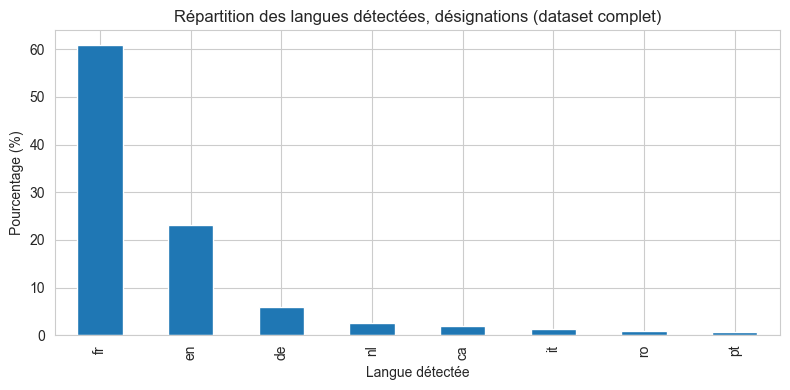

In [23]:
# Détection de langue sur l'ensemble du dataset (désignation seule, plus rapide)
# On utilise la désignation plutôt que text_concat : plus courte → détection plus rapide
# et toujours disponible (0 % de NaN)

if TQDM_AVAILABLE:
    from tqdm import tqdm
    tqdm.pandas()
    df_train["lang"] = df_train["designation"].progress_apply(detect_language_safe)
    df_test["lang"]  = df_test["designation"].apply(detect_language_safe)
else:
    df_train["lang"] = df_train["designation"].apply(detect_language_safe)
    df_test["lang"]  = df_test["designation"].apply(detect_language_safe)

print("Terminé.")

# Distribution globale
lang_dist = df_train["lang"].value_counts(normalize=True).mul(100).round(2)
display(lang_dist.to_frame("ratio_%").head(10))

plt.figure(figsize=(8, 4))
lang_dist.head(8).plot(kind="bar")
plt.title("Répartition des langues détectées, désignations (dataset complet)")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Langue détectée")
plt.tight_layout()
plt.show()

**Interprétation :** Sur l'ensemble des observations, **60,92 % des textes sont en français**, ce qui est cohérent avec un catalogue Rakuten France. On note :

- **23,03 % en anglais** : noms de marques, titres de livres/jeux/films donnés en anglais
- Les autres langues détectées (catalan, roumain, etc.) sont probablement des **faux positifs** sur des textes courts ou très techniques

Le FrenchStemmer appliqué est sous-optimal pour les textes anglais. Ce constat oriente vers un modèle d'embedding **multilingue** (mBERT, XLM-R) ou spécifique au français (CamemBERT) plutôt qu'une approche TF-IDF + stemmer pur.

---
### Key takeaways, Données textuelles

- `designation` : toujours présente, courte (70 car.), signal textuel fiable
- `description` : absente pour **35 % des produits**, très variable en longueur
- Pipeline NLP (stopwords + stemming) réduit le volume de **20 à 30 %** selon la variable
- Dataset principalement **français (61 %)** avec 23 % d'anglais → embedding multilingue conseillé
- La longueur du texte et la présence de description **varient selon la classe** (voir section 7)


### 5.4b Multilinguisme différencié par classe

Au-delà de la distribution globale des langues, nous analysons si certaines classes
sont structurellement plus multilingues que d'autres, ce qui affecterait l'efficacité
d'un modèle NLP monolingue français.


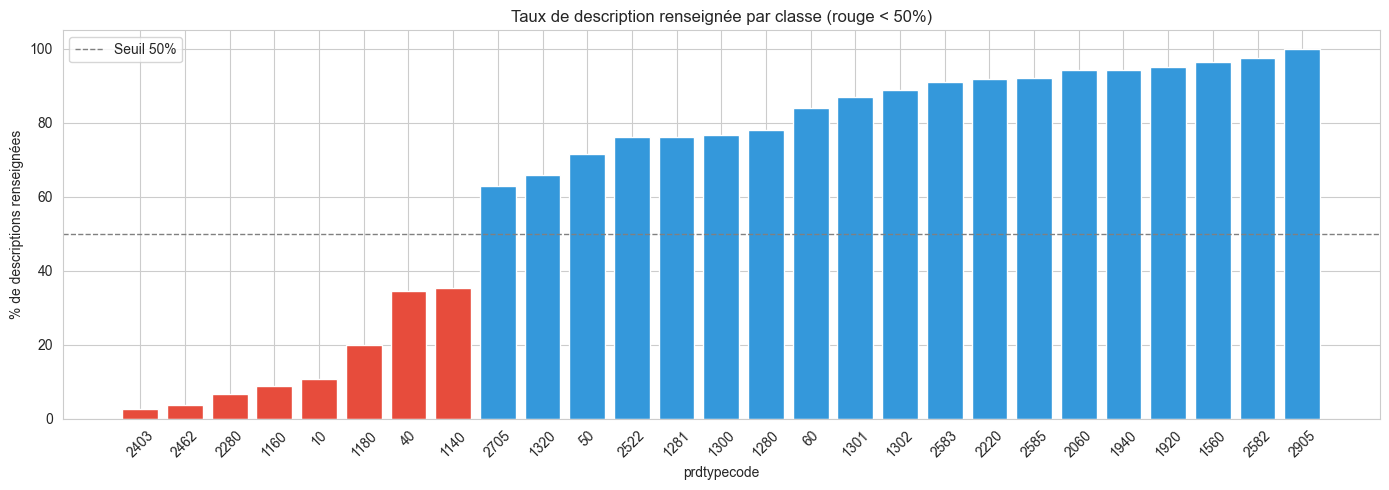


Taux de description par classe (%):
prdtypecode
2403      2.6
2462      3.7
2280      6.7
1160      8.8
10       10.8
1180     20.0
40       34.5
1140     35.4
2705     62.9
1320     66.0
50       71.7
2522     76.2
1281     76.2
1300     76.7
1280     78.1
60       84.0
1301     87.0
1302     88.9
2583     91.2
2220     92.0
2585     92.1
2060     94.3
1940     94.4
1920     95.2
1560     96.5
2582     97.6
2905    100.0


In [24]:
if "text_concat" in df_train.columns and target_col in df_train.columns:
    # Détection de langue déjà faite sur text_concat (sample)
    # Ici on utilise la colonne lang si elle existe, sinon on saute
    if "lang" not in df_train.columns:
        print("Colonne 'lang' non disponible, relancer après détection de langue complète.")
        print("Analyse de substitution : taux de description renseignée par classe.")

    # Taux de description renseignée par classe (proxy de la richesse textuelle par classe)
    desc_rate = df_train.groupby(target_col)["description"].apply(
        lambda x: x.notna().mean() * 100
    ).sort_values()

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["#e74c3c" if v < 50 else "#3498db" for v in desc_rate.values]
    ax.bar(desc_rate.index.astype(str), desc_rate.values, color=colors)
    ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="Seuil 50%")
    ax.set_xlabel("prdtypecode")
    ax.set_ylabel("% de descriptions renseignées")
    ax.set_title("Taux de description renseignée par classe (rouge < 50%)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("\nTaux de description par classe (%):")
    print(desc_rate.round(1).to_string())


### Constat - Taux de description très hétérogène selon les classes

Le taux de description renseignée varie **considérablement** selon la classe :
- Les classes les moins décrites (< 10 % de descriptions) devront s'appuyer
  **quasi exclusivement** sur la désignation et l'image pour être classifiées
- Les classes les mieux décrites (> 90 %) bénéficieront d'un signal textuel riche
  via la concaténation désignation + description

**Implication directe :** un modèle textuel pur aura des performances structurellement
inégales selon les classes. Les classes à faible taux de description sont celles
où **l'image est la plus critique** pour la classification.

Ce constat renforce la justification de l'approche multimodale et de la feature `has_description`.


### 5.5 Tokens les plus fréquents (texte nettoyé)

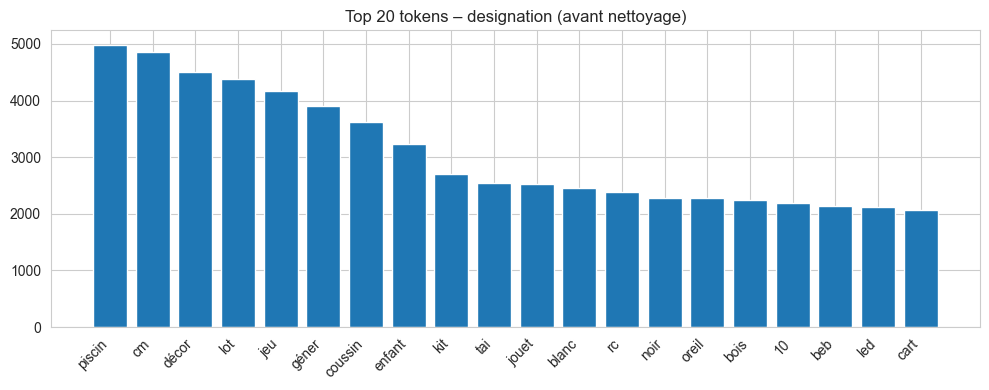

,token,count
0,piscin,4989
1,cm,4853
2,décor,4507
3,lot,4375
4,jeu,4165
5,géner,3901
6,coussin,3622
7,enfant,3242
8,kit,2699
9,tai,2546


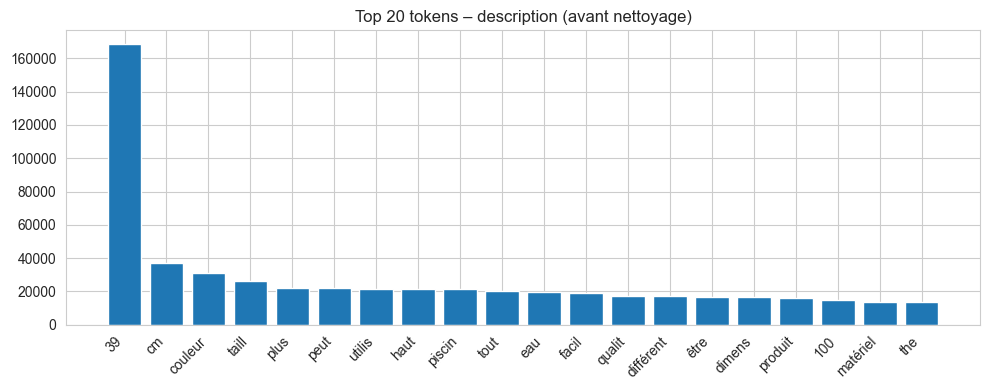

,token,count
0,39,168336
1,cm,36832
2,couleur,30858
3,taill,25996
4,plus,22124
5,peut,21881
6,utilis,21759
7,haut,21567
8,piscin,21313
9,tout,19991


In [25]:
for col in text_cols:
    top = get_top_tokens(df_train[f"{col}_clean"], n=20)
    plt.figure(figsize=(10, 4))
    plt.bar(top["token"], top["count"])
    plt.title(f"Top 20 tokens – {col} (avant nettoyage)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    #save_fig(f"top_tokens_{col}.png")
    plt.show()
    display(top)

### 5.6 World count per classe & Wordclouds

### 5.6.a Statistique des mots mes plus fréquent par class

In [26]:
print("Extraction des 10 mots les plus fréquents par catégorie de produit...")

top_words_per_class = {}
n_top_words = 10

df_train['text_concat'] = df_train['text_concat'].fillna("").astype(str)

grouped = df_train.groupby(target_col)

for prdtypecode, group in grouped:
    all_text = " ".join(group['text_concat'])
    
    word_counts = Counter(all_text.split())
    
    top_words = [word for word, count in word_counts.most_common(n_top_words)]
    top_words_per_class[prdtypecode] = top_words

df_top_words = pd.DataFrame.from_dict(
    top_words_per_class, 
    orient='index',
    columns=[f"Mot_{i+1}" for i in range(n_top_words)]
)

df_top_words.index.name = "prdtypecode"
df_top_words = df_top_words.sort_index()

display(df_top_words)

Extraction des 10 mots les plus fréquents par catégorie de produit...


,Mot_1,Mot_2,Mot_3,Mot_4,Mot_5,Mot_6,Mot_7,Mot_8,Mot_9,Mot_10
prdtypecode,,,,,,,,,,
10,the,of,and,in,livr,to,tom,edit,for,franc
40,import,39,jeu,produit,sous,langu,ni,titr,the,contrôleur
50,39,jeu,consol,nintendo,charg,ps4,manet,jeux,bouton,usb
60,consol,jeu,oui,gam,couleur,écran,34,jeux,39,portabl
1140,figurin,cm,pop,taill,star,war,the,nbsp,pvc,funko
1160,cart,yu,gi,oh,vf,magic,mtg,fr,rar,pokémon
1180,39,masqu,the,halloween,warhamm,of,figurin,jeu,heroclix,port
1280,39,enfant,jouet,beb,taill,couleur,peut,cadeau,haut,plus
1281,39,enfant,the,jouet,jeu,and,of,to,gam,card


In [27]:
# liste des mots les plus fréquents par classe a retirer des textes pour éviter le biais de classification
common_words_to_remove = ['the', '39', '01', 'of', 'cm', 'and', 'oui', 'gi', 'tai', 'taill', 'in', 'oh', 
                    '10', 'not', 'plus', 'sous', 'vf', '11', 'to', '34', '03', 'fr', '12', 'for', '09',
                    'or', '04']

words_to_remove_set = set(common_words_to_remove)
df_train['text_concat'] = df_train['text_concat'].apply(remove_custom_stopwords)

### 5.6.b Wordclouds

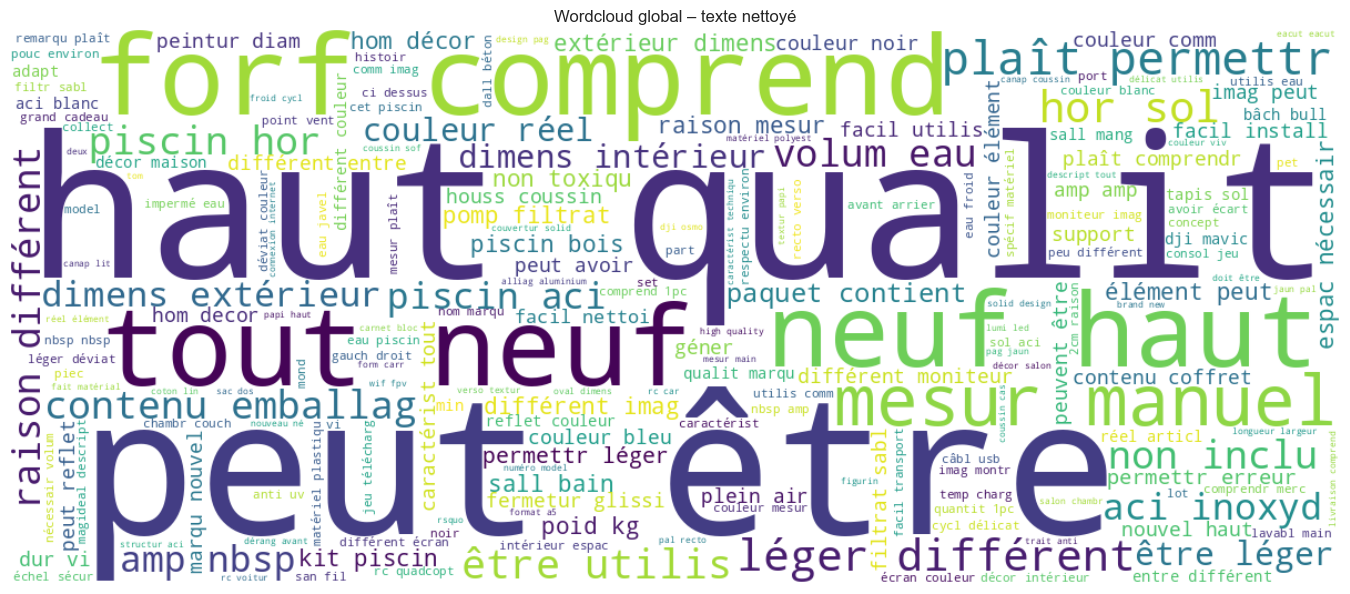

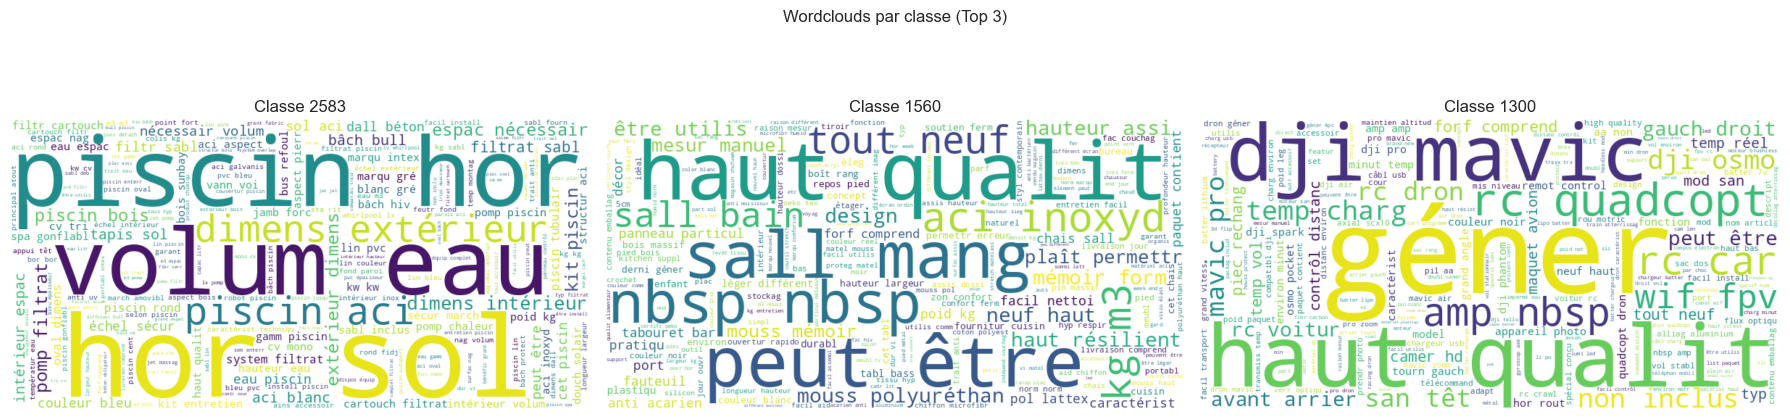

In [28]:
if WORDCLOUD_AVAILABLE and "text_concat" in df_train.columns:
    # Wordcloud global
    full_text = " ".join(df_train["text_concat"].dropna().astype(str))
    if full_text.strip():
        wc = WordCloud(width=1200, height=500, background_color="white").generate(full_text)
        plt.figure(figsize=(14, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title("Wordcloud global – texte nettoyé")
        plt.tight_layout()
        #save_fig("wordcloud_global.png")
        plt.show()

    # Wordclouds par classe (Top 3)
    if target_col is not None:
        top_classes_wc = df_train[target_col].value_counts().head(3).index.tolist()
        fig, axes = plt.subplots(1, len(top_classes_wc), figsize=(18, 5))
        if len(top_classes_wc) == 1:
            axes = [axes]
        for ax, cls in zip(axes, top_classes_wc):
            text_cls = " ".join(df_train.loc[df_train[target_col] == cls, "text_concat"].dropna().astype(str))
            if text_cls.strip():
                wc = WordCloud(width=800, height=400, background_color="white").generate(text_cls)
                ax.imshow(wc, interpolation="bilinear")
                ax.set_title(f"Classe {cls}")
            else:
                ax.text(0.5, 0.5, "Texte insuffisant", ha="center", va="center")
            ax.axis("off")
        plt.suptitle("Wordclouds par classe (Top 3)")
        plt.tight_layout()
        #save_fig("wordcloud_by_class.png")
        plt.show()
else:
    print("wordcloud non disponible.")

## 6. Analyse des données images

Les images constituent la seconde modalité du projet. Nous vérifions leur disponibilité, leurs dimensions, leur format couleur, la présence d'images corrompues, et nous visualisons des exemples par catégorie.


In [29]:
required_img_cols = {"imageid", "productid"}

if required_img_cols.issubset(df_train.columns):
    print("Extraction des métadonnées image (train)...")
    train_data = {"image_exists": [], "img_width": [], "img_height": [], "img_mode": []}
    for _, row in df_train.iterrows():
        path = get_image_path(IMAGE_TRAIN_DIR, row["imageid"], row["productid"])
        w, h, m = image_info(path)
        train_data["image_exists"].append(path.exists())
        train_data["img_width"].append(w)
        train_data["img_height"].append(h)
        train_data["img_mode"].append(m)

    for col, vals in train_data.items():
        df_train[col] = vals

    print("Extraction des métadonnées image (test)...")
    test_data = {"image_exists": [], "img_width": [], "img_height": [], "img_mode": []}
    for _, row in df_test.iterrows():
        path = get_image_path(IMAGE_TEST_DIR, row["imageid"], row["productid"])
        w, h, m = image_info(path)
        test_data["image_exists"].append(path.exists())
        test_data["img_width"].append(w)
        test_data["img_height"].append(h)
        test_data["img_mode"].append(m)

    for col, vals in test_data.items():
        df_test[col] = vals

    print("Métadonnées image ajoutées.")
else:
    print("Colonnes imageid/productid non trouvées – section image ignorée.")

Extraction des métadonnées image (train)...
Extraction des métadonnées image (test)...
Métadonnées image ajoutées.


Disponibilité des images (train) :


,ratio_%
image_exists,
True,100.0


,ratio_%
img_mode,
RGB,100.0


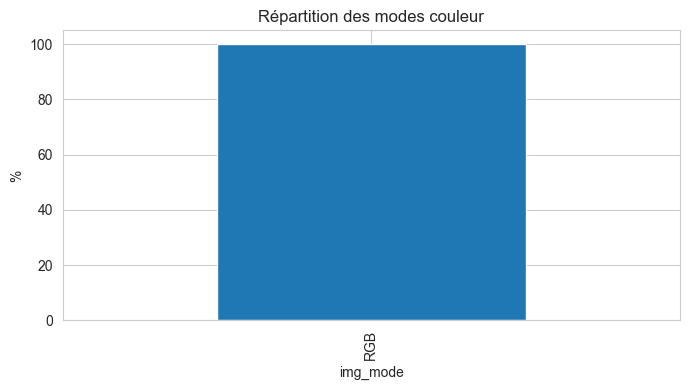

,count,mean,std,min,10%,25%,50%,75%,90%,max
img_width,84916.0,500.0,0.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0
img_height,84916.0,500.0,0.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0



Tailles d'images les plus fréquentes :


,img_width,img_height,count
0,500,500,84916


In [30]:
if "image_exists" in df_train.columns:
    # Taux de disponibilité
    avail = df_train["image_exists"].value_counts(normalize=True).mul(100).round(2)
    print("Disponibilité des images (train) :")
    display(avail.to_frame("ratio_%"))

    # Mode couleur
    mode_pct = df_train["img_mode"].dropna().value_counts(normalize=True).mul(100).round(2)
    if mode_pct.empty:
        raise RuntimeError(
            "Aucune métadonnée image disponible. Vérifier IMAGE_TRAIN_DIR, IMAGE_TEST_DIR, "
            "la construction des noms de fichiers et la disponibilité réelle des images."
        )
    display(mode_pct.to_frame("ratio_%"))

    plt.figure(figsize=(7, 4))
    mode_pct.plot(kind="bar")
    plt.title("Répartition des modes couleur")
    plt.ylabel("%")
    plt.tight_layout()
    #save_fig("image_mode_distribution.png")
    plt.show()

    # Statistiques descriptives tailles
    if "img_width" in df_train.columns:
        display(df_train[["img_width", "img_height"]].describe(
            percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).T)

        most_common_sizes = (
            df_train.groupby(["img_width", "img_height"]).size()
            .sort_values(ascending=False).head(10).reset_index(name="count")
        )
        print("\nTailles d'images les plus fréquentes :")
        display(most_common_sizes)

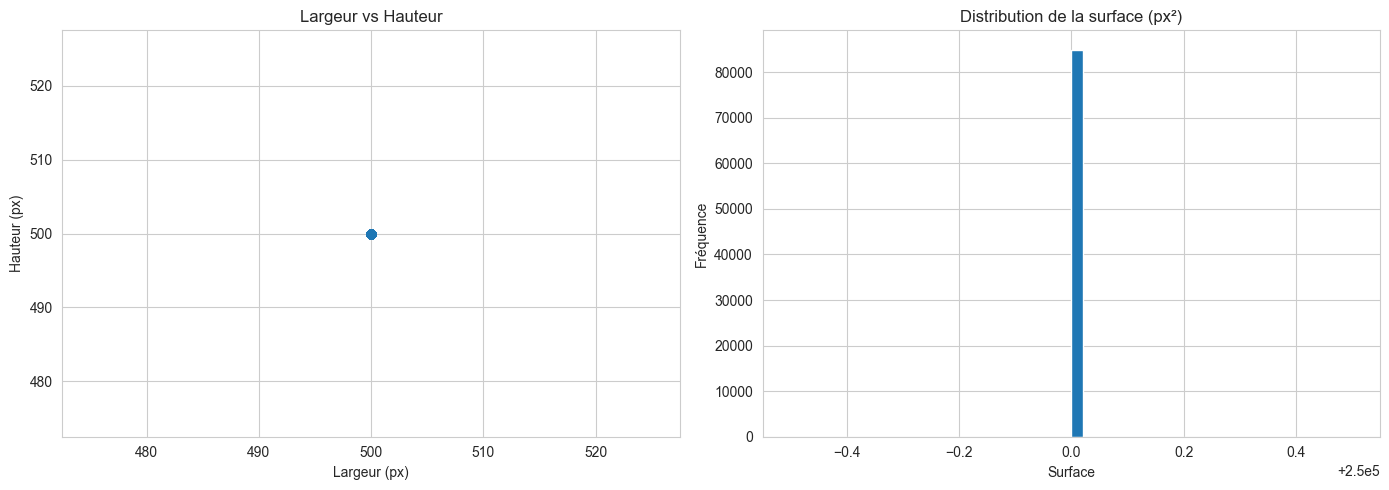

In [31]:
if "img_width" in df_train.columns and "img_height" in df_train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(df_train["img_width"], df_train["img_height"], alpha=0.2)
    axes[0].set_title("Largeur vs Hauteur")
    axes[0].set_xlabel("Largeur (px)")
    axes[0].set_ylabel("Hauteur (px)")

    (df_train["img_width"] * df_train["img_height"]).dropna().hist(bins=50, ax=axes[1])
    axes[1].set_title("Distribution de la surface (px²)")
    axes[1].set_xlabel("Surface")
    axes[1].set_ylabel("Fréquence")

    plt.tight_layout()
    #save_fig("image_dimensions.png")
    plt.show()

In [32]:
# Détection d'images corrompues (échantillon)
if required_img_cols.issubset(df_train.columns):
    sample_idx = df_train.sample(min(5000, len(df_train)), random_state=42).index
    corrupted = []
    for idx in sample_idx:
        row = df_train.loc[idx]
        path = get_image_path(IMAGE_TRAIN_DIR, row["imageid"], row["productid"])
        corrupted.append(is_corrupted_image(path))
    print(f"Taux d'images corrompues/illisibles (échantillon {len(sample_idx)}) : {np.mean(corrupted)*100:.2f}%")

Taux d'images corrompues/illisibles (échantillon 5000) : 0.00%


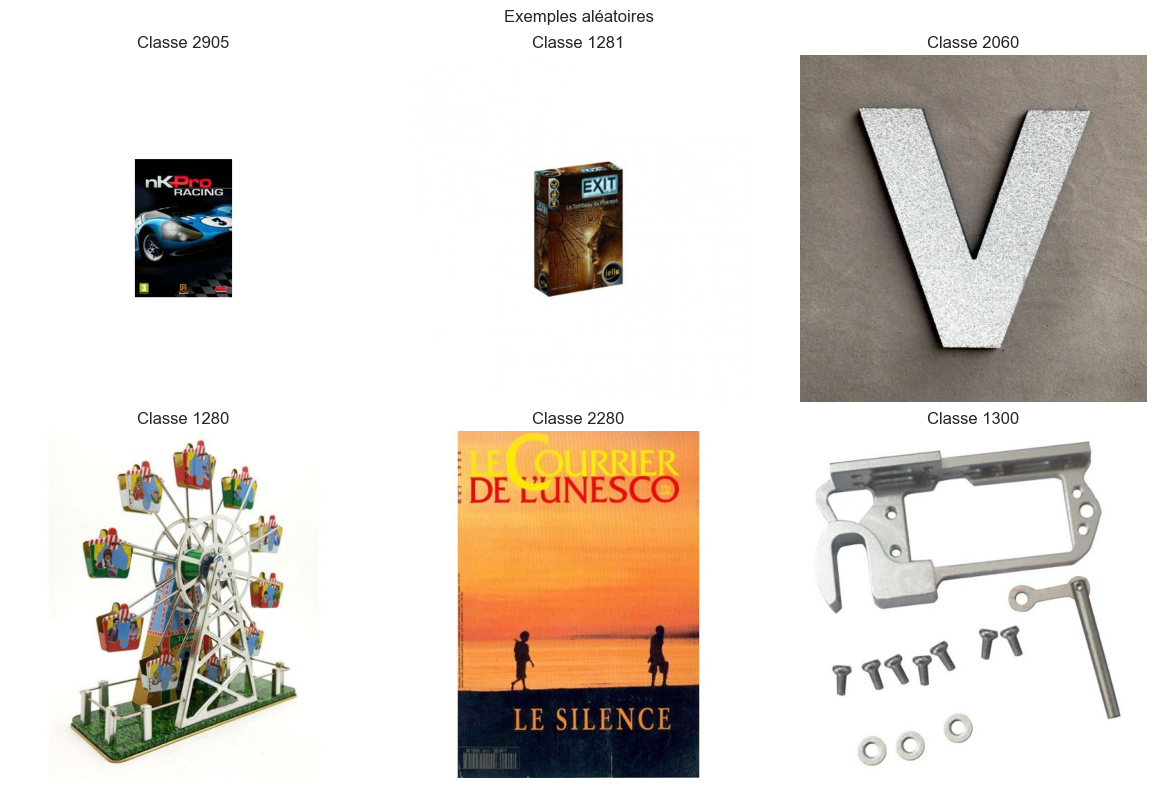

In [33]:
# Exemples aléatoires
if required_img_cols.issubset(df_train.columns):
    sample_rows = df_train.sample(6, random_state=42)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, sample_rows.iterrows()):
        img_path = get_image_path(IMAGE_TRAIN_DIR, row["imageid"], row["productid"])
        if img_path.exists():
            ax.imshow(Image.open(img_path))
            ax.set_title(f"Classe {row[target_col]}" if target_col else "")
        else:
            ax.text(0.5, 0.5, "Image non trouvée", ha="center", va="center")
        ax.axis("off")
    plt.suptitle("Exemples aléatoires")
    plt.tight_layout()
    #save_fig("image_sample_random.png")
    plt.show()

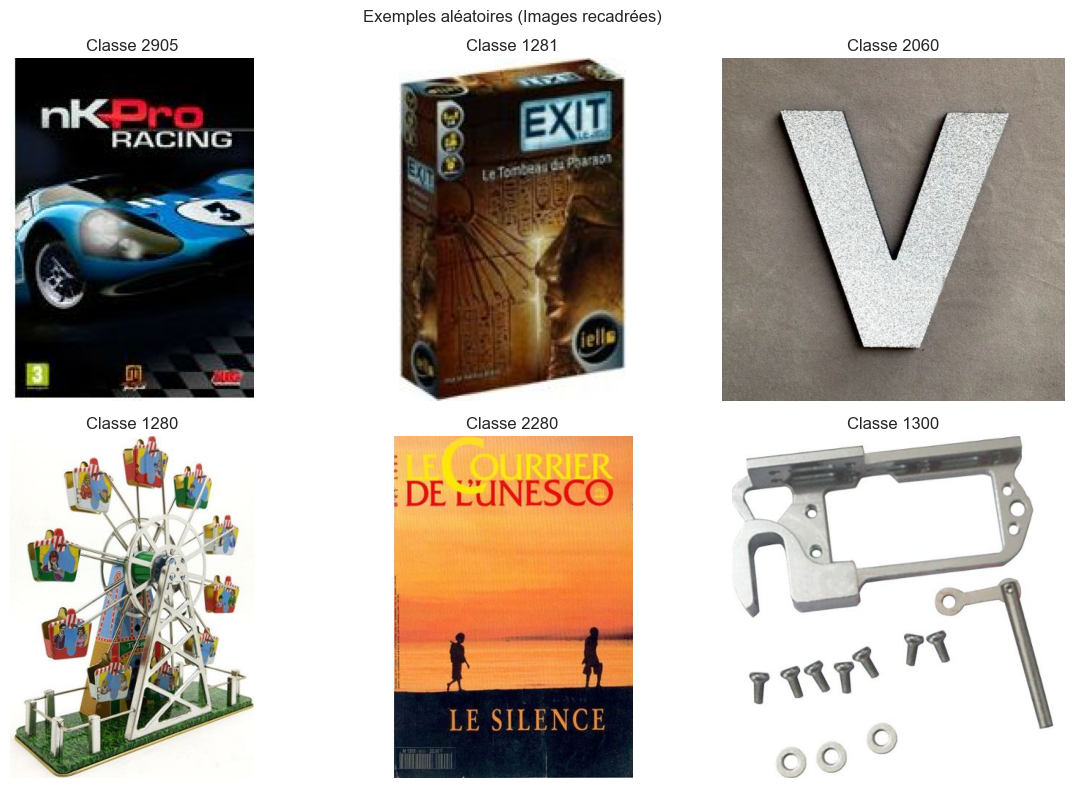

In [34]:
# exemple de recadrage automatique des images (crop)
if required_img_cols.issubset(df_train.columns):
    sample_rows = df_train.sample(6, random_state=42)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for ax, (_, row) in zip(axes, sample_rows.iterrows()):
        img_path = get_image_path(IMAGE_TRAIN_DIR, row["imageid"], row["productid"])
        
        if img_path.exists():
            cropped_img_bgr = crop_image_borders(img_path, tol=15)
            
            if cropped_img_bgr is not None:
                cropped_img_rgb = cv2.cvtColor(cropped_img_bgr, cv2.COLOR_BGR2RGB)
                ax.imshow(cropped_img_rgb)
            else:
                ax.text(0.5, 0.5, "Erreur lecture", ha="center", va="center")
                
            ax.set_title(f"Classe {row[target_col]}" if target_col else "")
        else:
            ax.text(0.5, 0.5, "Image non trouvée", ha="center", va="center")
            
        ax.axis("off")
        
    plt.suptitle("Exemples aléatoires (Images recadrées)")
    plt.tight_layout()
    #save_fig("image_sample_random_cropped.png")
    plt.show()

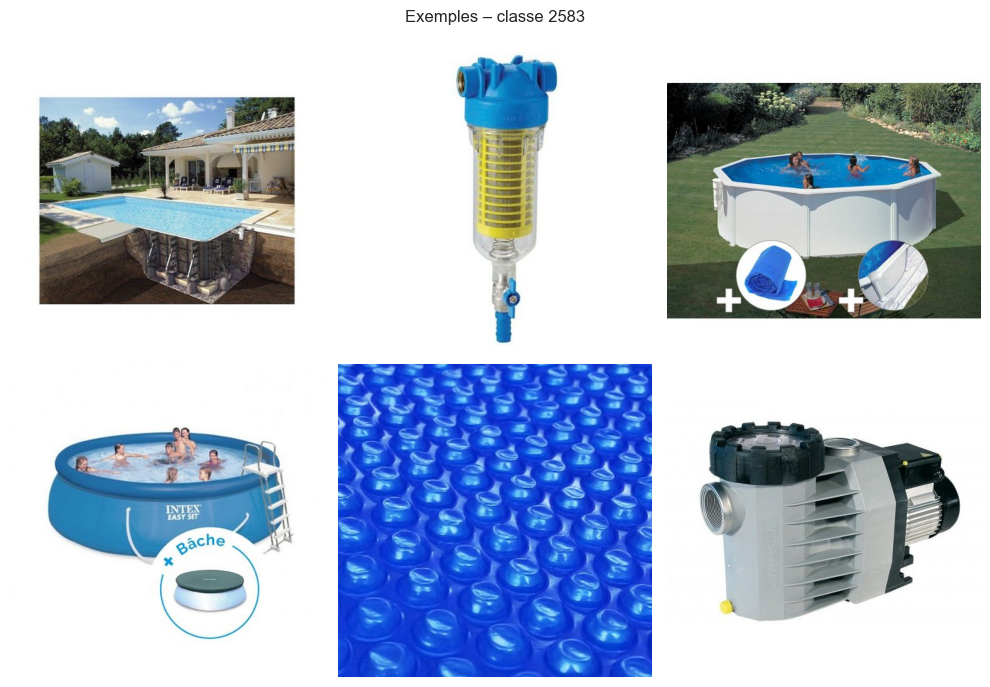

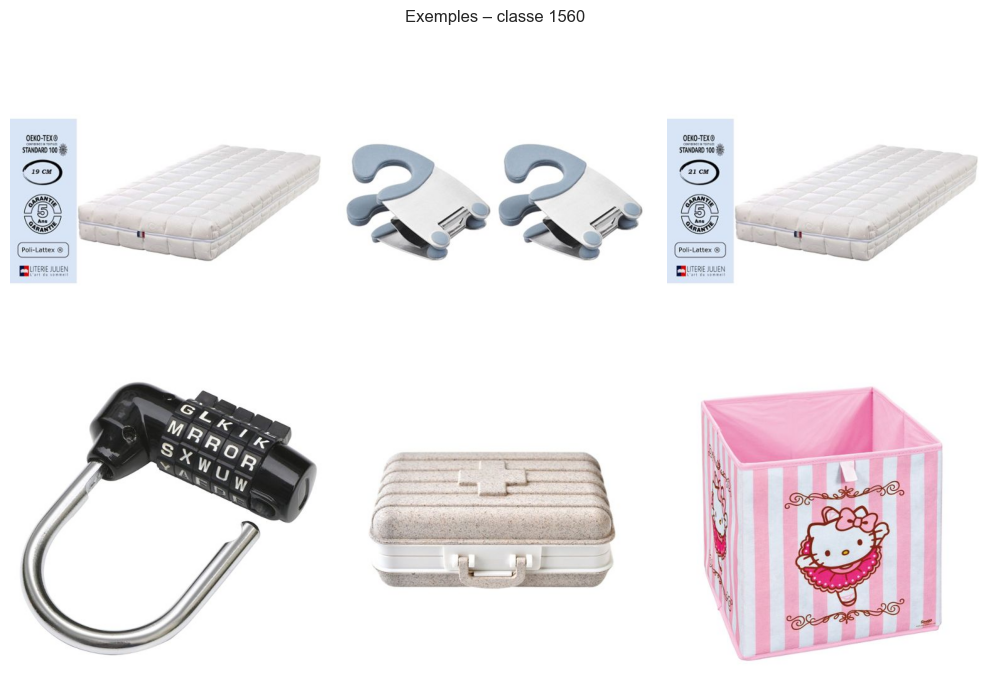

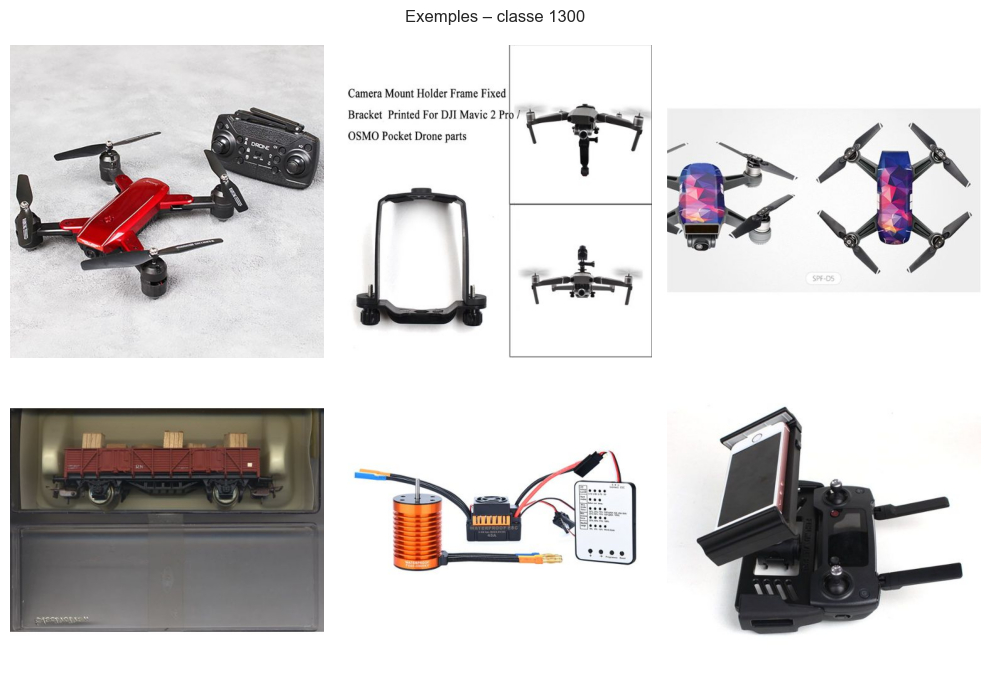

In [35]:
# Grille d'images par catégorie (Top 3 classes)
if target_col is not None and required_img_cols.issubset(df_train.columns):
    for cls in df_train[target_col].value_counts().head(3).index:
        subset = df_train[df_train[target_col] == cls].sample(
            min(6, (df_train[target_col] == cls).sum()), random_state=42)
        fig, axes = plt.subplots(2, 3, figsize=(10, 7))
        axes = axes.flatten()
        for ax, (_, row) in zip(axes, subset.iterrows()):
            img_path = get_image_path(IMAGE_TRAIN_DIR, row["imageid"], row["productid"])
            if img_path.exists():
                try:
                    ax.imshow(Image.open(img_path))
                except Exception:
                    ax.text(0.5, 0.5, "illisible", ha="center", va="center")
            else:
                ax.text(0.5, 0.5, "absente", ha="center", va="center")
            ax.axis("off")
        for ax in axes[len(subset):]:
            ax.axis("off")
        plt.suptitle(f"Exemples – classe {cls}")
        plt.tight_layout()
        #save_fig(f"image_sample_class_{cls}.png")
        plt.show()

**Interprétation :** L'analyse des métadonnées image révèle un résultat remarquable : **100 % des images sont disponibles, en mode RGB, et mesurent exactement 500×500 pixels**. Aucune image manquante et aucune hétérogénéité de dimensions ou de mode couleur. L'échantillon contrôlé de 5 000 images ne contient aucune image corrompue.

**Conséquences pratiques :**
- Pas de redimensionnement nécessaire en dehors de l'adaptation aux CNN (ex. 224×224 pour ResNet/EfficientNet)
- Pas de conversion RGB nécessaire
- Les features `aspect_ratio`, `image_area` ont une **variance nulle** → non informatives dans ce dataset

**Ce que les images nous apprennent visuellement :**  
La grille par catégorie montre que certaines classes ont une **cohérence visuelle forte** (ex. produits piscine : objets ronds, bleus, fonds blancs), tandis que d'autres sont plus hétérogènes visuellement. Cette cohérence intra-classe suggère qu'un CNN pré-entraîné pourra capter des patterns visuels discriminants. Les classes visuellement proches entre elles nécessiteront le signal textuel pour être différenciées, ce qui justifie l'approche multimodale.

---
### Key takeaways, Données images

- **100 %** des images disponibles, en RGB 500×500, aucune image corrompue dans l'échantillon de 5 000 images
- Les métadonnées simples (taille, mode) sont **non discriminantes** (variance nulle)
- La valeur discriminante réside dans le **contenu visuel** : CNN pré-entraîné recommandé
- Certaines classes ont une forte cohérence visuelle → modèle image seul potentiellement efficace
- D'autres classes visuellement proches nécessiteront la **fusion texte + image**


### 6.2 Pipeline de preprocessing image

Les images étant uniformément 500×500 RGB, nous définissons ici la fonction
de preprocessing qui sera utilisée lors de la modélisation.


In [36]:
from PIL import Image as PILImage
import numpy as np

# Paramètres cibles pour les modèles de transfer learning
IMAGE_SIZE = (224, 224)
IMAGE_MEAN = [0.485, 0.456, 0.406]  # Moyenne ImageNet (RGB)
IMAGE_STD  = [0.229, 0.224, 0.225]  # Écart-type ImageNet (RGB)

def preprocess_image(image_path, target_size=IMAGE_SIZE):
    """
    Charge une image, la redimensionne à target_size,
    la convertit en RGB et retourne un array normalisé dans [0, 1].
    Retourne None si l'image est illisible.
    """
    try:
        with PILImage.open(image_path) as img:
            img = img.convert("RGB")
            img = img.resize(target_size, PILImage.LANCZOS)
            arr = np.array(img) / 255.0
            return arr
    except Exception:
        return None

# Test sur un exemple réel
if required_img_cols.issubset(df_train.columns):
    sample_row = df_train.dropna(subset=["imageid", "productid"]).iloc[0]
    test_path  = get_image_path(IMAGE_TRAIN_DIR, sample_row["imageid"], sample_row["productid"])

    if test_path.exists():
        arr = preprocess_image(str(test_path))
        if arr is not None:
            print(f"Shape après preprocessing : {arr.shape}")
            print(f"Valeurs min / max         : {arr.min():.3f} / {arr.max():.3f}")
            print(f"Dtype                     : {arr.dtype}")
            print()

print("Pipeline image défini :")
print(f"  Redimensionnement : {IMAGE_SIZE[0]}×{IMAGE_SIZE[1]} px (interpolation LANCZOS)")
print(f"  Normalisation     : valeurs dans [0, 1]")
print(f"  Normalisation ImageNet (mean/std) : appliquée dans le DataLoader au Rendu 2")


Shape après preprocessing : (224, 224, 3)
Valeurs min / max         : 0.051 / 1.000
Dtype                     : float64

Pipeline image défini :
  Redimensionnement : 224×224 px (interpolation LANCZOS)
  Normalisation     : valeurs dans [0, 1]
  Normalisation ImageNet (mean/std) : appliquée dans le DataLoader au Rendu 2


**Justification du pipeline image :**

| Étape | Valeur | Raison |
|---|---|---|
| Conversion RGB | Toujours appliquée | Déjà RGB dans ce dataset ; robustesse pour d'autres datasets |
| Resize 224×224 | LANCZOS | Standard pour ResNet / EfficientNet / ViT pré-entraînés |
| Normalisation [0,1] | ÷ 255 | Compatibilité avec les frameworks PyTorch / TensorFlow |
| Normalisation ImageNet | mean/std par canal | Appliquée dans le DataLoader (Rendu 2), pas ici |

La normalisation ImageNet est volontairement reportée à la phase de modélisation
pour éviter de modifier les images sauvegardées et conserver leur lisibilité visuelle
dans ce notebook d'exploration.


## 7. Analyses croisées (features ↔ cible)

Cette section identifie des relations entre les variables explicatives et la variable cible, ainsi qu'entre elles, et les valide par des tests statistiques.


### 7.1 Corrélation entre longueurs textuelles

,méthode,corrélation
0,pearson,0.1715
1,spearman,0.3428


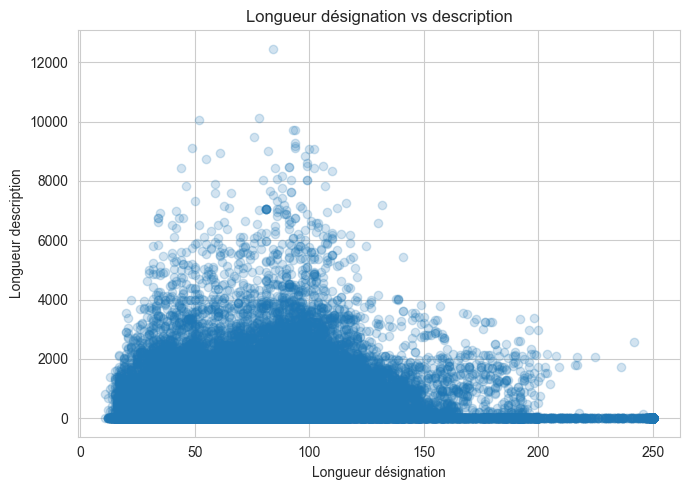

In [37]:
if "designation_length" in df_train.columns and "description_length" in df_train.columns:
    corr_p = df_train[["designation_length", "description_length"]].corr(method="pearson").iloc[0, 1]
    corr_s = df_train[["designation_length", "description_length"]].corr(method="spearman").iloc[0, 1]

    display(pd.DataFrame({"méthode": ["pearson", "spearman"],
                          "corrélation": [round(corr_p, 4), round(corr_s, 4)]}))

    plt.figure(figsize=(7, 5))
    plt.scatter(df_train["designation_length"], df_train["description_length"], alpha=0.2)
    plt.title("Longueur désignation vs description")
    plt.xlabel("Longueur désignation")
    plt.ylabel("Longueur description")
    plt.tight_layout()
    #save_fig("scatter_text_lengths.png")
    plt.show()

### 7.2 Présence de description selon la classe (χ²)

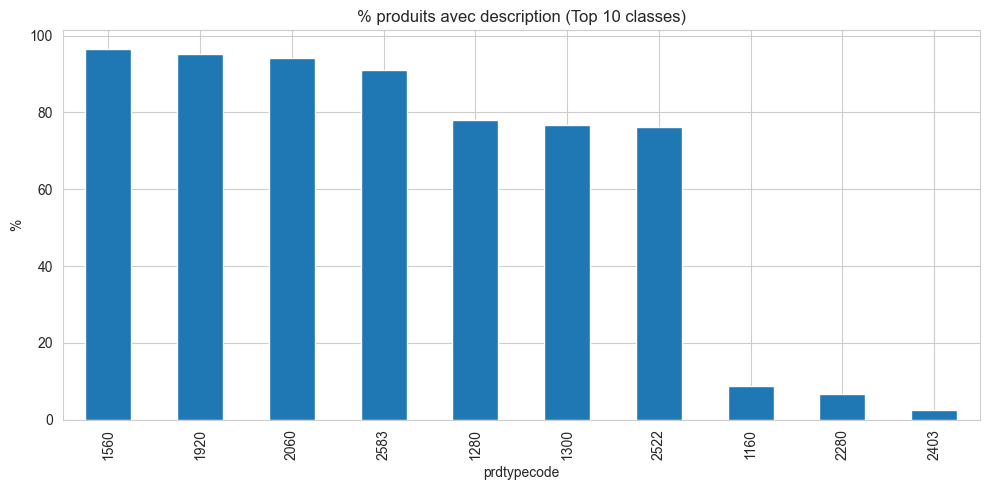

,chi2,p_value,dof
0,31214.35,0.0,9


In [38]:
if target_col is not None and "description" in df_train.columns:
    df_train["has_description"] = (df_train["description"].fillna("").astype(str).str.strip() != "").astype(int)
    df_test["has_description"]  = (df_test["description"].fillna("").astype(str).str.strip() != "").astype(int)

    top10 = df_train[target_col].value_counts().head(10).index
    temp  = df_train[df_train[target_col].isin(top10)]

    desc_by_class = temp.groupby(target_col)["has_description"].mean().sort_values(ascending=False) * 100
    plt.figure(figsize=(10, 5))
    desc_by_class.plot(kind="bar")
    plt.title("% produits avec description (Top 10 classes)")
    plt.ylabel("%")
    plt.tight_layout()
    #save_fig("has_description_by_class.png")
    plt.show()

    # Test χ²
    ct = pd.crosstab(temp[target_col], temp["has_description"])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    display(pd.DataFrame({"chi2": [round(chi2, 2)], "p_value": [p_val], "dof": [dof]}))

**Interprétation :** Sur les 10 classes les plus fréquentes, le test du χ² donne une statistique de **31 214** avec une **p-value de 0,0**, rejetant massivement l'hypothèse d'indépendance. La présence d'une description est donc **statistiquement liée à la catégorie** dans ce sous-ensemble, certaines classes ont systématiquement leurs produits décrits, d'autres non. Ce déséquilibre intra-dataset renforce l'importance de la feature `has_description` et confirme qu'un modèle purement textuel aura des performances inégales selon les classes.


### 7.3 Longueur du texte par classe (Kruskal-Wallis)

,mean,median,std,min,max
prdtypecode,,,,,
2060,1098.272582,939.0,900.232937,16,9565
1560,1005.528681,835.0,835.044001,19,12535
1300,857.428940,687.0,935.413591,17,9217
1920,816.466651,692.0,576.964871,17,6388
2583,776.412283,558.0,700.692138,18,6780
1280,702.324846,538.0,853.009748,15,9803
2522,333.217478,246.0,430.189834,17,6367
2280,126.102101,91.0,117.685589,12,1986
2403,73.901341,54.0,64.526853,12,834


<Figure size 1200x500 with 0 Axes>

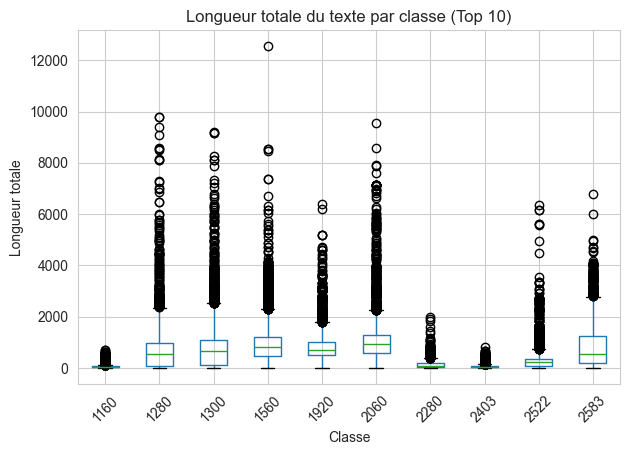

,H_kruskal,p_value,n_classes
0,4356.92,0.0,5


In [39]:
if target_col is not None and "text_total_length" in df_train.columns:
    top10 = df_train[target_col].value_counts().head(10).index
    temp  = df_train[df_train[target_col].isin(top10)]

    display(temp.groupby(target_col)["text_total_length"].agg(
        ["mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False))

    plt.figure(figsize=(12, 5))
    temp.boxplot(column="text_total_length", by=target_col, rot=45)
    plt.title("Longueur totale du texte par classe (Top 10)")
    plt.suptitle("")
    plt.xlabel("Classe")
    plt.ylabel("Longueur totale")
    plt.tight_layout()
    #save_fig("text_length_by_class.png")
    plt.show()

    # Test de Kruskal-Wallis
    top5   = df_train[target_col].value_counts().head(5).index
    temp5  = df_train[df_train[target_col].isin(top5)]
    groups = [temp5.loc[temp5[target_col] == c, "text_total_length"].dropna() for c in top5]
    stat, p_val = kruskal(*groups)
    display(pd.DataFrame({"H_kruskal": [round(stat, 2)], "p_value": [p_val], "n_classes": [len(top5)]}))

### 7.4 Top tokens par classe

,classe,token,count
0,2583,piscin,25824
1,2583,eau,10942
2,2583,dimens,7572
3,2583,pomp,7061
4,2583,filtrat,6723
5,2583,aci,5979
6,2583,filtr,5081
7,2583,sol,4970
8,2583,kit,4166
9,2583,sabl,4099


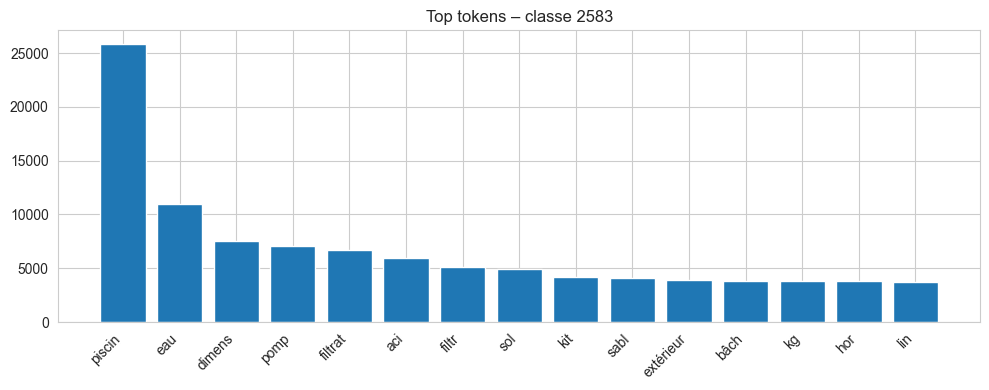

In [40]:
if target_col is not None and "text_concat" in df_train.columns:
    top10_classes = df_train[target_col].value_counts().head(10).index
    rows = []
    for cls in top10_classes:
        tokens = " ".join(df_train.loc[df_train[target_col] == cls, "text_concat"].fillna("").astype(str)).split()
        for token, count in Counter(tokens).most_common(15):
            rows.append({"classe": cls, "token": token, "count": count})
    top_tokens_df = pd.DataFrame(rows)

    display(top_tokens_df.head(30))

    # Visualisation pour la classe majoritaire
    cls0 = df_train[target_col].value_counts().index[0]
    temp = top_tokens_df[top_tokens_df["classe"] == cls0]
    plt.figure(figsize=(10, 4))
    plt.bar(temp["token"], temp["count"])
    plt.title(f"Top tokens – classe {cls0}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    #save_fig(f"top_tokens_class_{cls0}.png")
    plt.show()

**Interprétation :** Chaque classe possède un **vocabulaire distinctif** fortement ancré dans son domaine :
- Classe **2583** (piscines & accessoires) : termes `piscin`, `eau`, `pomp`, `filtrat`, `bâch`, vocabulaire très spécifique
- Classe **1560** (mobilier/décoration) : termes `couleur`, `haut`, `mater`, `dimens`

Cette spécificité lexicale confirme que les variables textuelles portent un **fort signal discriminant** exploitable directement par des modèles NLP.


### 7.5 Corrélation texte / image

In [41]:
if "text_total_length" in df_train.columns and "img_width" in df_train.columns:
    image_area = df_train["img_width"] * df_train["img_height"]
    corr_p = df_train["text_total_length"].corr(image_area, method="pearson")
    corr_s = df_train["text_total_length"].corr(image_area, method="spearman")

    display(pd.DataFrame({
        "méthode": ["pearson", "spearman"],
        "corrélation texte_length / image_area": [round(corr_p, 4) if pd.notna(corr_p) else "NaN", 
                                                   round(corr_s, 4) if pd.notna(corr_s) else "NaN"]
    }))
    
    print()
    print("► Résultat NaN : toutes les images ont exactement la même surface (500×500 px),")
    print("  donc image_area est une constante → variance = 0 → corrélation non calculable.")
    print("  Ce n'est pas une erreur de code, mais un résultat informatif :")
    print("  la relation texte-image ne peut pas être évaluée à partir de dimensions constantes.")


,méthode,corrélation texte_length / image_area
0,pearson,NaN
1,spearman,NaN



► Résultat NaN : toutes les images ont exactement la même surface (500×500 px),
  donc image_area est une constante → variance = 0 → corrélation non calculable.
  Ce n'est pas une erreur de code, mais un résultat informatif :
  les deux modalités sont indépendantes en termes de métadonnées.


### Key takeaways, Analyses croisées

- **Corrélation désignation/description** (Pearson 0,17, Spearman 0,34) : faible, les deux variables apportent des informations **complémentaires**, les conserver toutes les deux
- **Présence de description vs classe** (χ² = 31 214, p ≈ 0, sur les 10 classes les plus fréquentes) : la description n'est **pas manquante au hasard**, `has_description` est une feature pertinente
- **Longueur du texte vs classe** (Kruskal-Wallis, p ≈ 0, sur les 5 classes les plus fréquentes) : la longueur varie significativement selon la catégorie → feature auxiliaire utile
- **Vocabulaire par classe** : signal discriminant fort → texte très informatif pour la classification
- **Corrélation texte/image** : NaN (variance image nulle), cette relation ne peut pas être évaluée à partir de la surface des images


## 8. Feature engineering

Sur la base des analyses précédentes, nous construisons les variables dérivées qui enrichiront le dataset pour la modélisation. **Toutes les features sont créées ici une seule fois**, sans duplication.

| Feature | Type | Justification |
|---|---|---|
| `designation_length` | Numérique | Longueur titre en caractères, varie selon la classe |
| `description_length` | Numérique | Longueur description, varie selon la classe |
| `text_total_length` | Numérique | Longueur combinée, signal synthétique |
| `designation_word_count` | Numérique | Nombre de mots titre |
| `description_word_count` | Numérique | Nombre de mots description |
| `text_total_word_count` | Numérique | Total mots combiné |
| `has_description` | Binaire | Flag absence/présence, non aléatoire selon la classe (χ² significatif) |
| lang | Catégorielle | Langue détectée de la désignation, varie selon la classe |
| `aspect_ratio` | Numérique | Ratio largeur/hauteur (constant = 1,0 ici) |
| `image_area` | Numérique | Surface en pixels (constant = 250 000 ici) |
| `is_rgb` | Binaire | Mode couleur (constant = 1 ici) |
| `is_grayscale` | Binaire | Mode niveaux de gris (constant = 0 ici) |

**Note :** les features image sont constantes dans ce dataset ; elles sont conservées pour la robustesse de la pipeline.


In [42]:
# Features images 
if "img_width" in df_train.columns and "img_height" in df_train.columns:
    for df in [df_train, df_test]:
        df["aspect_ratio"] = df["img_width"] / df["img_height"].replace(0, np.nan)
        df["image_area"]   = df["img_width"] * df["img_height"]

if "img_mode" in df_train.columns:
    for df in [df_train, df_test]:
        df["is_rgb"]       = (df["img_mode"] == "RGB").astype(int)
        df["is_grayscale"] = (df["img_mode"] == "L").astype(int)

if "image_area" in df_train.columns:
    q10 = df_train["image_area"].quantile(0.10)
    q90 = df_train["image_area"].quantile(0.90)
    for df in [df_train, df_test]:
        df["image_is_small"] = (df["image_area"] <= q10).astype(int)
        df["image_is_large"] = (df["image_area"] >= q90).astype(int)

print("Features image créées.")

# Features texte
# has_description déjà créé en section 7.2 ; on s'assure qu'il existe
if "has_description" not in df_train.columns and "description" in df_train.columns:
    for df in [df_train, df_test]:
        df["has_description"] = (df["description"].fillna("").astype(str).str.strip() != "").astype(int)

print("Features texte créées.")

# Récapitulatif
feature_cols = [c for c in [
    "designation_length", "description_length",
    "designation_word_count", "description_word_count",
    "text_total_length", "text_total_word_count",
    "has_description", "lang",
    "img_width", "img_height", "aspect_ratio",
    "image_area", "image_is_small", "image_is_large",
    "is_rgb", "is_grayscale"
] if c in df_train.columns]

display(df_train[feature_cols].head())

Features image créées.
Features texte créées.


,designation_length,description_length,designation_word_count,description_word_count,text_total_length,text_total_word_count,has_description,lang,img_width,img_height,aspect_ratio,image_area,image_is_small,image_is_large,is_rgb,is_grayscale
0,88,0,14,0,88,14,0,de,500,500,1.0,250000,1,1,1,0
1,206,0,39,0,206,39,0,fr,500,500,1.0,250000,1,1,1,0
2,76,760,12,109,836,121,1,de,500,500,1.0,250000,1,1,1,0
3,63,0,10,0,63,10,0,de,500,500,1.0,250000,1,1,1,0
4,20,213,4,34,233,38,1,ca,500,500,1.0,250000,1,1,1,0


## 9. Traitement des valeurs manquantes

In [43]:
# Texte : remplacement NaN par chaîne vide
for col in text_cols:
    df_train[col] = df_train[col].fillna("")
    df_test[col]  = df_test[col].fillna("")

# Dimensions image : médiane
for col in ["img_width", "img_height"]:
    if col in df_train.columns:
        med = df_train[col].median()
        df_train[col] = df_train[col].fillna(med)
        df_test[col]  = df_test[col].fillna(med)

# Mode couleur : valeur sentinelle
if "img_mode" in df_train.columns:
    df_train["img_mode"] = df_train["img_mode"].fillna("UNKNOWN")
    df_test["img_mode"]  = df_test["img_mode"].fillna("UNKNOWN")

# Features dérivées : médiane (après remplissage des dimensions)
for col in ["aspect_ratio", "image_area"]:
    if col in df_train.columns:
        med = df_train[col].replace([np.inf, -np.inf], np.nan).median()
        df_train[col] = df_train[col].replace([np.inf, -np.inf], np.nan).fillna(med)
        df_test[col]  = df_test[col].replace([np.inf, -np.inf], np.nan).fillna(med)

print("Valeurs manquantes après traitement (train) :")
remaining_na = df_train[feature_cols].isna().sum()
display(remaining_na[remaining_na > 0] if remaining_na.sum() > 0 else "Aucune valeur manquante.")

Valeurs manquantes après traitement (train) :


'Aucune valeur manquante.'

**Justification des choix de traitement :**

| Variable | Traitement | Raison |
|---|---|---|
| `designation`, `description` | → chaîne vide | Conserver la ligne pour ne pas perdre l'image associée |
| `img_width`, `img_height` | → médiane | Robuste aux outliers ; sans effet ici (toutes images 500×500) |
| `img_mode` | → `"UNKNOWN"` | Distinguer les cas manquants sans les confondre avec les valeurs existantes |
| `aspect_ratio`, `image_area` | → médiane | Après remplissage des dimensions |

**Pas de normalisation/standardisation à ce stade** : elle sera effectuée dans la pipeline de modélisation (via `StandardScaler` dans un `Pipeline` scikit-learn) pour éviter toute **fuite d'information** entre train et validation.

**Résultat : 0 valeur manquante** dans `df_train` et `df_test` après traitement.


### Key takeaways, Preprocessing & Feature engineering

- **Textes manquants → chaîne vide** : aucune observation n'est perdue ; l'image reste exploitable même sans texte
- **0 valeur manquante** dans le dataset final (train et test) après traitement
- **Pipeline NLP unique** : lowercasing → HTML → URLs → caractères spéciaux → stopwords → stemming, appliquée une seule fois sur `designation` et `description`
- **Réduction de 20–30 %** du volume de tokens après nettoyage : moins de bruit pour la vectorisation
- **`has_description`** : feature binaire justifiée statistiquement (χ² p ≈ 0), la description n'est pas manquante au hasard
- **Pas de normalisation à ce stade** : sera appliquée dans la pipeline de modélisation (StandardScaler dans un Pipeline scikit-learn) pour éviter la fuite d'information


## 10. Projection vers la modélisation

Les analyses menées permettent d'anticiper des décisions méthodologiques concrètes pour le Rendu 2 :

| Enjeu identifié | Valeur observée | Stratégie envisagée |
|---|---|---|
| Déséquilibre des classes | Ratio min/max : 0,075 ; CV : 0,67 | Split stratifié, `class_weight='balanced'`, métriques macro/weighted F1 |
| Texte multilingue | 60,92 % FR, 23,03 % EN | CamemBERT ou mBERT/XLM-R plutôt que TF-IDF + FrenchStemmer pur |
| Description souvent absente | 35,09 % des produits | Feature `has_description`, modèle robuste à l'absence de description |
| Images homogènes (500×500 RGB) | 100 % disponibles, 0 % corrompues sur l'échantillon de 5 000 images | Redimensionnement 224×224 pour CNN pré-entraînés, normalisation ImageNet |
| Features image à variance nulle | aspect_ratio = 1,0 constant | Exclure ces features des modèles numériques |
| Vocabulaire distinctif par classe | Signal lexical fort (ex. classe 2583) | TF-IDF en baseline puis embeddings contextuels |
| Deux modalités complémentaires | Texte + image | Modèles séparés puis **late fusion** |

### Stratégie de modélisation envisagée (Rendu 2)

```
Baseline
├── Modèle texte seul   : TF-IDF + LogisticRegression / LinearSVC
├── Modèle image seul   : CNN pré-entraîné (EfficientNet-B0) en feature extractor
└── Modèle multimodal   : late fusion des probabilités texte + image

Modèles avancés (Rendu 3)
├── Texte               : CamemBERT fine-tuné
├── Image               : Fine-tuning CNN complet
└── Fusion              : Concaténation d'embeddings ou stacking
```


## 11. Dataset final prêt pour la modélisation

Cette section répond explicitement aux six questions que tout modèle doit pouvoir poser avant l'entraînement.

---

### Question 1, Quelle est l'entrée textuelle ?

Trois champs textuels nettoyés sont disponibles :

| Champ | Contenu | Vides (train) |
|---|---|---|
| `designation_clean` | Titre du produit nettoyé | 1 valeur vide (0,0 %) |
| `description_clean` | Description longue, souvent absente | 29 943 valeurs vides (35,3 %) |
| `text_concat` | `designation_clean` + `description_clean` concaténés | 1 valeur vide (0,0 %) |

**Entrée recommandée pour les modèles textuels :** `text_concat`, il agrège les deux sources et n'est vide que pour une observation.

---

### Question 2, Quelle est l'entrée image ?

- **Chemin d'accès :** `IMAGE_TRAIN_DIR / image_{imageid}_product_{productid}.jpg`  
- **Format :** JPEG, RGB, **500×500 pixels**, 100 % disponibles, 0 % corrompues sur l'échantillon de 5 000 images  
- **Format cible pour CNN pré-entraînés :** redimensionner à **224×224**, normalisation ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

---

### Question 3, Quelles sont les features structurées supplémentaires ?

| Feature | Type | Valeur informative |
|---|---|---|
| `has_description` | Binaire |  Oui, liée à la classe (χ² p ≈ 0) |
| `designation_length` | Numérique |  Varie selon la classe (Kruskal-Wallis p ≈ 0) |
| `description_length` | Numérique |  Varie selon la classe |
| `text_total_length` | Numérique |  Signal synthétique |
| `designation_word_count` | Numérique |  Complémentaire à la longueur |
| `description_word_count` | Numérique |  Complémentaire à la longueur |
| `lang` | Catégorielle |  Langue détectée de la désignation, varie selon la classe |
| `aspect_ratio`, `image_area`, `is_rgb` | Numérique/Binaire |  Variance nulle dans ce dataset |

Les features image à variance nulle peuvent être exclues des modèles tabulaires.

---

### Question 4, Quelle est la variable cible ?

`prdtypecode`, entier parmi **27 classes** (sous-ensemble du challenge Rakuten France).  
Effectifs : min **764**, max **10 209**, médiane **2 671**.

---

### Question 5, Quelle est la stratégie de split prévu ?

```python
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    df_train, df_train[target_col],
    test_size=0.20,
    random_state=42,
    stratify=df_train[target_col]   # indispensable, classes déséquilibrées
)
```

Ratio : **80 % entraînement / 20 % validation**, stratifié sur `prdtypecode`.

---

### Question 6, Quels baselines sont prévus ?

| Modèle | Entrée | Algorithme |
|---|---|---|
| **Texte seul (baseline)** | `text_concat` TF-IDF | LogisticRegression / LinearSVC |
| **Image seule (baseline)** | Images 224×224 | EfficientNet-B0 pré-entraîné (feature extractor) |
| **Multimodal (baseline)** | Texte + Image | Late fusion : moyenne des probabilités |
| **Multimodal avancé** | Embeddings texte + image | Concaténation + classificateur final |

**Métrique principale :** `weighted F1-score` (robuste au déséquilibre des classes).  
**Métrique secondaire :** `macro F1-score` (pénalise les classes minoritaires mal classifiées).


In [44]:
# Récapitulatif du dataset final
print("=" * 65)
print("DATASET FINAL, RÉCAPITULATIF")
print("=" * 65)

print(f"\n Volumétrie")
print(f"  Train : {len(df_train):,} observations × {df_train.shape[1]} colonnes")
print(f"  Test  : {len(df_test):,} observations  × {df_test.shape[1]} colonnes")
print(f"  Classes : {df_train[target_col].nunique()} (prdtypecode)")

print(f"\n Entrée TEXTE")
for c in ["designation_clean", "description_clean", "text_concat"]:
    if c in df_train.columns:
        empty = (df_train[c].str.strip() == "").sum()
        print(f"  {c:<25} | {empty:>6,} vides ({empty/len(df_train)*100:.1f}%)")

print(f"\n  Entrée IMAGE")
print(f"  Chemin  : IMAGE_TRAIN_DIR / image_{{imageid}}_product_{{productid}}.jpg")
print(f"  Format  : RGB 500×500 px → redimensionner à 224×224 pour CNN")
if "image_exists" in df_train.columns:
    print(f"  Disponibles : {df_train['image_exists'].sum():,} / {len(df_train):,} (100 %)")

print(f"\n Features numériques supplémentaires")
aux_feats = [c for c in [
    "designation_length", "description_length", "text_total_length",
    "designation_word_count", "description_word_count", "text_total_word_count",
    "has_description"
] if c in df_train.columns]
for c in aux_feats:
    print(f"  {c}")

print(f"\n Variable cible")
vc = df_train[target_col].value_counts()
print(f"  {target_col}, {vc.shape[0]} classes")
print(f"  Min : {vc.min():,} obs. | Max : {vc.max():,} obs. | Médiane : {vc.median():.0f}")

print(f"\n  Stratégie de split recommandée")
print(f"  Méthode : train_test_split avec stratify={target_col}")
print(f"  Ratio   : 80 % entraînement / 20 % validation")
print(f"  Seed    : 42")

print(f"\n Valeurs manquantes après traitement")
print(f"  Train : {df_train.isna().sum().sum()} | Test : {df_test.isna().sum().sum()}")


DATASET FINAL, RÉCAPITULATIF

 Volumétrie
  Train : 84,916 observations × 27 colonnes
  Test  : 13,812 observations  × 26 colonnes
  Classes : 27 (prdtypecode)

 Entrée TEXTE
  designation_clean         |      1 vides (0.0%)
  description_clean         | 29,943 vides (35.3%)
  text_concat               |      1 vides (0.0%)

  Entrée IMAGE
  Chemin  : IMAGE_TRAIN_DIR / image_{imageid}_product_{productid}.jpg
  Format  : RGB 500×500 px → redimensionner à 224×224 pour CNN
  Disponibles : 84,916 / 84,916 (100 %)

 Features numériques supplémentaires
  designation_length
  description_length
  text_total_length
  designation_word_count
  description_word_count
  text_total_word_count
  has_description

 Variable cible
  prdtypecode, 27 classes
  Min : 764 obs. | Max : 10,209 obs. | Médiane : 2671

  Stratégie de split recommandée
  Méthode : train_test_split avec stratify=prdtypecode
  Ratio   : 80 % entraînement / 20 % validation
  Seed    : 42

 Valeurs manquantes après traitement
  Trai

### Ce que le modèle reçoit

| Modalité | Entrée concrète | Format |
|---|---|---|
| **Texte** | `text_concat` (désignation + description nettoyées) | Chaîne tokenisée |
| **Image** | Fichier JPEG via `imageid` + `productid` | RGB 224×224, normalisé ImageNet |
| **Features aux.** | `has_description`, longueurs de texte | Vecteur numérique standardisé |
| **Cible** | `prdtypecode` | Entier parmi 27 classes |

### Plan de modélisation, Rendu 2

1. **Baseline texte** : TF-IDF (sur `text_concat`) + LogisticRegression  
2. **Baseline image** : CNN pré-entraîné (EfficientNet-B0) en feature extractor + classificateur  
3. **Fusion multimodale** : late fusion (moyenne pondérée ou stacking) des prédictions texte + image  

Toutes les évaluations se feront sur le jeu de validation stratifié, avec le **weighted F1-score** comme métrique principale.


## 12. Export des datasets et résumé final

In [45]:
# Colonnes présentes dans le dataset final
model_ready_cols = [c for c in [
    "designation_clean",
    "description_clean",
    "text_concat",
    "designation_length",
    "description_length",
    "designation_word_count",
    "description_word_count",
    "text_total_length",
    "text_total_word_count",
    "has_description",
    "lang",
    "img_width", "img_height", "img_mode",
    "aspect_ratio", "image_area",
    "image_is_small", "image_is_large",
    "is_rgb", "is_grayscale", "image_exists",
    target_col
] if c in df_train.columns]

print("Colonnes disponibles pour la modélisation :")
display(pd.DataFrame({"colonne": model_ready_cols}))

# Préparation du contrat de données attendu par le notebook 02
df_train["text_combined"] = df_train["text_concat"].fillna("").astype(str)
empty_text_mask = df_train["text_combined"].str.strip().eq("")
df_train.loc[empty_text_mask, "text_combined"] = (
    df_train.loc[empty_text_mask, "designation_clean"].fillna("").astype(str)
)
df_train["image_path"] = df_train.apply(
    lambda row: str(get_image_path(
        IMAGE_TRAIN_DIR, row["imageid"], row["productid"]
    )),
    axis=1
)

required_modeling_cols = [
    "designation_clean", "description_clean", "text_combined",
    "image_path", "productid", "imageid", target_col
]
missing_modeling_cols = [c for c in required_modeling_cols if c not in df_train.columns]
if missing_modeling_cols:
    raise ValueError(
        f"Colonnes requises par le notebook 02 absentes : {missing_modeling_cols}"
    )

sample_paths_ok = df_train["image_path"].head(10).apply(lambda p: Path(p).is_file())
if not sample_paths_ok.all():
    raise FileNotFoundError(
        "Au moins un chemin image de l'échantillon d'export est invalide."
    )

print("Colonnes requises par le notebook 02 : OK")
print("Chemins image valides sur l'échantillon :", int(sample_paths_ok.sum()), "/", len(sample_paths_ok))

# Sauvegarde des exports existants et de l'export pour le notebook 02
df_train.to_csv(PROCESSED_DIR / "train_clean.csv", index=False)
df_test.to_csv(PROCESSED_DIR  / "test_clean.csv",  index=False)
df_train.to_csv(PROCESSED_DIR / "df_train_processed.csv", index=False)

print("\nDatasets sauvegardés dans :", PROCESSED_DIR)
print("Lignes exportées dans df_train_processed.csv :", len(df_train))


Colonnes disponibles pour la modélisation :


,colonne
0,designation_clean
1,description_clean
2,text_concat
3,designation_length
4,description_length
5,designation_word_count
6,description_word_count
7,text_total_length
8,text_total_word_count
9,has_description


Colonnes requises par le notebook 02 : OK
Chemins image valides sur l'échantillon : 10 / 10

Datasets sauvegardés dans : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\processed
Lignes exportées dans df_train_processed.csv : 84916


In [46]:
# Résumé synthétique
summary = {
    "n_train_rows":              len(df_train),
    "n_test_rows":               len(df_test),
    "n_train_columns":           df_train.shape[1],
    "target_column":             target_col,
    "n_classes":                 int(df_train[target_col].nunique()) if target_col else None,
    "missing_values_train":      int(df_train.isna().sum().sum()),
    "missing_values_test":       int(df_test.isna().sum().sum()),
    "stopwords_applied":         len(FRENCH_STOPWORDS) > 0,
    "stemming_applied":          STEMMER is not None,
    "langdetect_applied":        LANGDETECT_AVAILABLE,
}

summary_df = pd.DataFrame(summary.items(), columns=["indicateur", "valeur"])
display(summary_df)

,indicateur,valeur
0,n_train_rows,84916
1,n_test_rows,13812
2,n_train_columns,29
3,target_column,prdtypecode
4,n_classes,27
5,missing_values_train,0
6,missing_values_test,0
7,stopwords_applied,True
8,stemming_applied,True
9,langdetect_applied,True


## 13. Conclusion

Cette première phase d'exploration a permis de **caractériser précisément le dataset Rakuten**
(sous-ensemble 27 classes) et de poser des bases solides pour la modélisation du Rendu 2.

---

### Synthèse des résultats clés

| Dimension | Résultat principal | Impact modélisation |
|---|---|---|
| **Périmètre** | Sous-ensemble de 27 classes (challenge original : 1 000+) | Tâche plus simple mais déséquilibre persistant |
| **Cible** | 27 classes, ratio max/min ~13,4, CV 0,67 | Split stratifié, métriques macro/weighted F1 |
| **Doublons texte** | Désignations identiques → classes différentes | Preuve empirique de la nécessité du multimodal |
| **Texte** | Désignation : 100 % présente ; Description : 35 % absente | `has_description` comme feature ; multimodal indispensable |
| **Description/classe** | Taux de 2,6 % à 100 % selon la classe | Classes sans description → image critique |
| **Langue** | ~61 % FR, ~23 % EN + autres | mBERT / multilingual-MiniLM plutôt que modèle FR pur |
| **NLP** | Réduction 20–30 % des tokens (stopwords + stemming) | Texte nettoyé prêt pour vectorisation |
| **Images** | 100 % disponibles, RGB 500×500, 0 % corrompues sur l'échantillon de 5 000 images | CNN pré-entraîné, resize 224×224 |
| **Signal texte** | Vocabulaire distinctif par classe (χ², Kruskal-Wallis p ≈ 0) | Texte fortement informatif |
| **Corrélation texte/image** | NaN, variance image nulle (toutes 500×500) | Relation non évaluable à partir de la surface, fusion à tester sur le contenu |

---

### Les 6 constats les plus importants

1. **Des désignations identiques correspondent à des classes différentes**, dans ces cas,
   l'image est la seule source d'information discriminante. C'est une preuve empirique directe
   de la nécessité du multimodal, indépendamment des taux de valeurs manquantes.

2. **La description est absente pour 35 % des produits, et ce n'est pas aléatoire**, certaines
   classes ont quasi systématiquement leurs descriptions renseignées (> 90 %), d'autres non (< 10 %).
   Une approche texte seul sera structurellement pénalisée sur les classes sans description.

3. **Le vocabulaire est distinctif par classe**, les tokens les plus fréquents diffèrent fortement
   entre catégories. Le texte porte un signal discriminant fort et directement exploitable.

4. **Les images sont parfaitement homogènes en métadonnées** (100 % RGB 500×500, aucune image corrompue sur l'échantillon de 5 000 images),
     la valeur discriminante réside dans le contenu visuel. Un CNN pré-entraîné est l'outil naturel.

5. **Le dataset est multilingue de façon structurée**, certaines classes sont majoritairement
   anglophones ou germanophones. Un modèle NLP multilingue est indispensable pour couvrir
   uniformément toutes les classes sans biais linguistique.

6. **Le déséquilibre est modéré mais réel** (ratio max/min ~13,4, CV 0,67), gérable avec un split stratifié
   et des métriques macro/weighted F1, sans sur-échantillonnage nécessaire a priori.

---

### Dataset livré

| Fichier | Observations | Colonnes | Valeurs manquantes |
|---|---|---|---|
| `train_clean.csv` | 84 916 | 29 | 0 |
| `test_clean.csv` | 13 812 | 26 | 0 |
| `df_train_processed.csv` | 84 916 | 29 | 0 |

Pipeline NLP : lowercasing → HTML → URLs → caractères spéciaux → stopwords → stemming

---

### Prochaines étapes (Rendu 2)

1. **Baseline texte** : TF-IDF sur `text_concat` + LogisticRegression / LinearSVC
2. **Baseline image** : EfficientNet-B0 ou ResNet50 pré-entraîné en feature extractor
3. **Modèle texte avancé** : `paraphrase-multilingual-MiniLM-L12-v2` ou CamemBERT
4. **Fusion multimodale** : late fusion des probabilités texte + image
5. **Évaluation** : weighted F1-score sur validation stratifiée (80/20, seed 42),
   analyse d'erreurs par classe avec focus sur les classes minoritaires


<br>
<h1>Annex Analyse supplémentaire</h1>

## 14. Enrichissements EDA

Approfondissent l'analyse initiale sur quatre axes :  
**sémantique**, **visuel**, **multimodal** et **robustesse du prétraitement**.


### 14.0 Distribution des classes en fonction du nombre de produit 


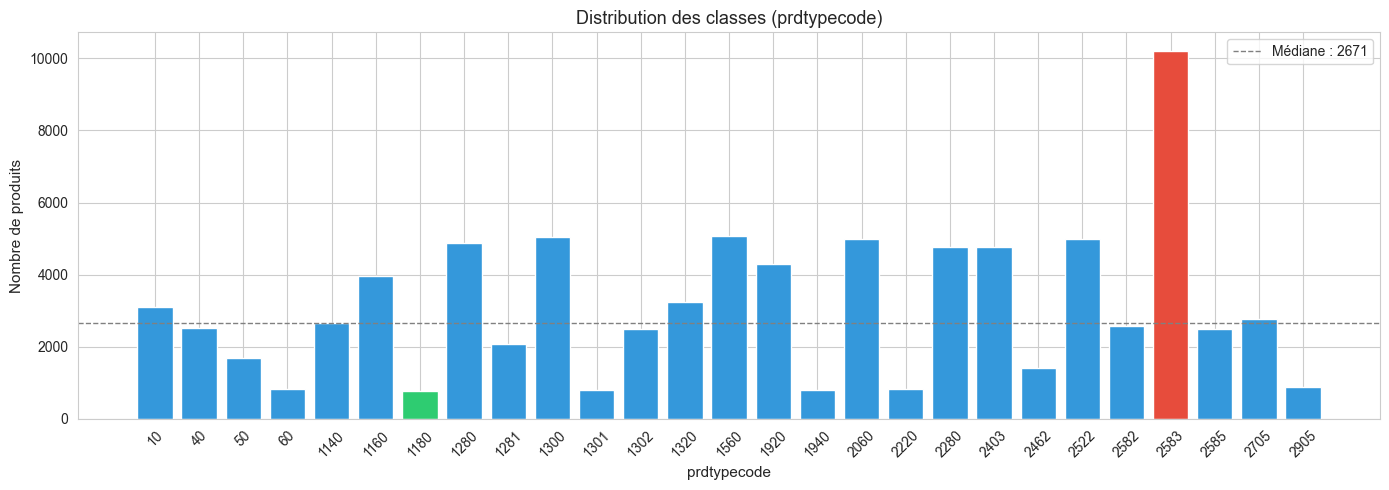

In [47]:
class_counts = df_train["prdtypecode"].value_counts().sort_index()

# Visualisation de la distribution des classes
fig, ax = plt.subplots(figsize=(14, 5))

colors = ["#e74c3c" if v == class_counts.max() else
          "#2ecc71" if v == class_counts.min() else
          "#3498db" for v in class_counts.values]

ax.bar(class_counts.index.astype(str), class_counts.values, color=colors)
ax.set_xlabel("prdtypecode", fontsize=11)
ax.set_ylabel("Nombre de produits", fontsize=11)
ax.set_title("Distribution des classes (prdtypecode)", fontsize=13)
ax.tick_params(axis="x", rotation=45)

# Ligne médiane
ax.axhline(class_counts.median(), color="gray", linestyle="--", linewidth=1,
           label=f"Médiane : {class_counts.median():.0f}")
ax.legend()

plt.tight_layout()
plt.show()


### 14.1 Profils statistiques par classe 

**Objectif : → Identifier les classes **text-dependent** vs **image-dependent** via une étude de correlation.
- longueur moyenne du texte (designation + description)
- taux de description présente
- langue dominante
- nombre d'observations
- Présence de la description

In [48]:
# Profil de description et designation par classe 

def dominant_lang(series):
    vc = series.value_counts()
    return vc.index[0] if len(vc) else "unknown"

# Colonnes de longueur, recalcul si absentes
for col, src in [("designation_length", "designation"),
                 ("description_length", "description"),
                 ("text_total_length",  None)]:
    if col not in df_train.columns:
        if col == "text_total_length":
            df_train["text_total_length"] = (
                df_train["designation_length"] + df_train["description_length"])
        else:
            df_train[col] = df_train[src].fillna("").str.len()

if "has_description" not in df_train.columns:
    df_train["has_description"] = df_train["description"].notna() & (df_train["description"].str.strip() != "")

class_profile = df_train.groupby(target_col).agg(
    n_obs               = ("designation", "count"),
    desig_len_mean      = ("designation_length", "mean"),
    desc_len_mean       = ("description_length", "mean"),
    text_total_len_mean = ("text_total_length", "mean"),
    pct_has_desc        = ("has_description", "mean"),
).round(1)

if "lang" in df_train.columns:
    lang_dom = df_train.groupby(target_col)["lang"].agg(dominant_lang)
    class_profile["lang_dominant"] = lang_dom

class_profile = class_profile.sort_values("n_obs", ascending=False)
print("Profil statistique par classe (trié par volume) :")
display(class_profile[:5])


Profil statistique par classe (trié par volume) :


,n_obs,desig_len_mean,desc_len_mean,text_total_len_mean,pct_has_desc,lang_dominant
prdtypecode,,,,,,
2583,10209,57.6,718.9,776.4,0.9,fr
1560,5073,83.3,922.2,1005.5,1.0,fr
1300,5045,92.0,765.4,857.4,0.8,fr
2060,4993,85.8,1012.4,1098.3,0.9,fr
2522,4989,72.9,260.3,333.2,0.8,fr


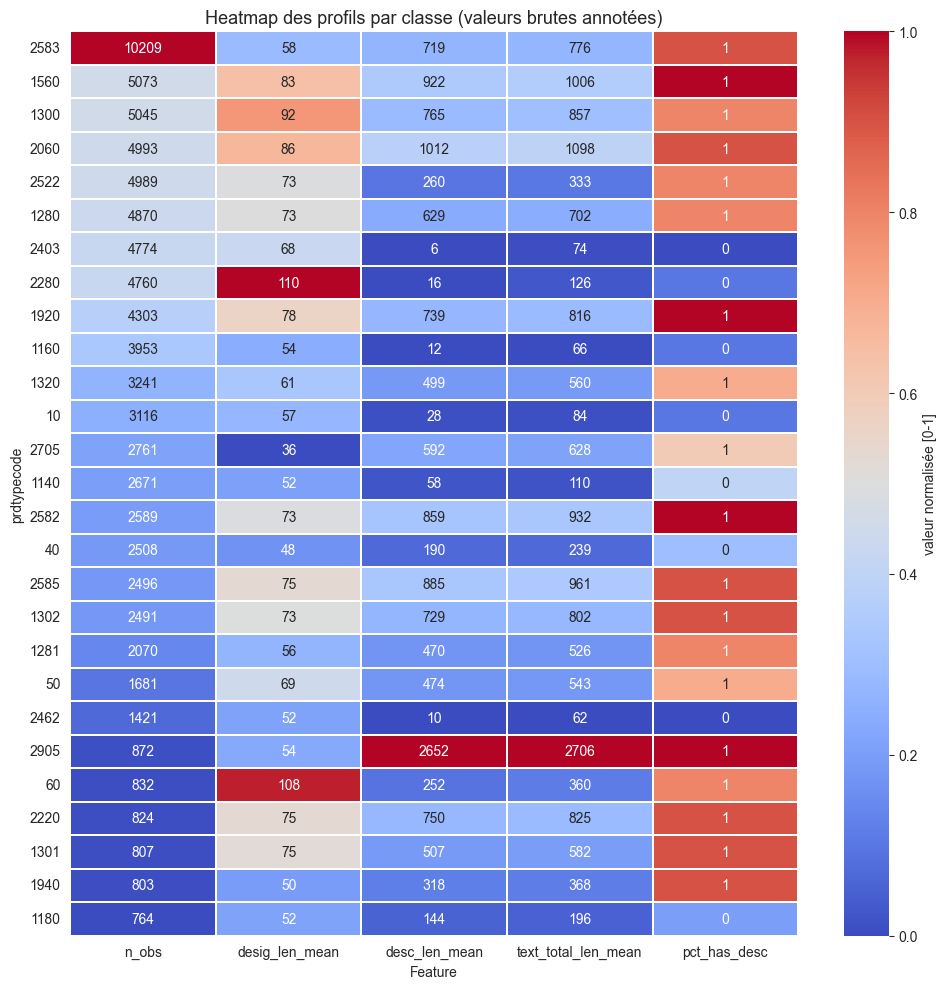

In [49]:
# Correlation entre les classes / aux stats moyennes de description et de designation
num_cols = ["n_obs", "desig_len_mean", "desc_len_mean", "text_total_len_mean", "pct_has_desc"]
heat_data = class_profile[num_cols].copy()
heat_norm  = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(heat_norm, annot=heat_data.round(0), fmt="g", cmap="coolwarm",
            linewidths=0.3, ax=ax, cbar_kws={"label": "valeur normalisée [0-1]"})
ax.set_title("Heatmap des profils par classe (valeurs brutes annotées)", fontsize=13)
ax.set_ylabel("prdtypecode")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.show()

### Analyse croisée

La distribution de l'absence de description n'est pas reparti dans toutes les classes.

Huit classes ont moins de 40 % de descriptions renseignées. Elles dépendent donc davantage de la désignation et de l'image.


### Variable supplémentaire pour les analyse
Les statiques suivantes contribue a caractériser chaque classes 

Feature additionnelle:

-  `n_obs`               
-  `desig_len_mean`      
-  `desc_len_mean`
-  `text_total_len_mean`



<br>

### 14.2 Analyse visuelle des images

**Objectif :** aller au-delà des métadonnées (taille : height, wigth, format, spectre) et inspecter le **contenu** des images, les images .

- **Histogramme des couleurs dominantes** par classe (canaux R, G, B moyens)
- **Score de netteté** (variance du Laplacien), détecter les images floues
- **Luminosité & contraste moyen**, hétérogénéité intra-classe


In [50]:
#  Analyse visuelle des images 

from scipy.ndimage import laplace

N_IMG_SAMPLE = 1_000   # limite pour rester rapide

def laplacian_variance(img_array_gray):
    """Score de netteté : variance du filtre Laplacien (plus c'est élevé, plus c'est net)."""
    return float(np.var(laplace(img_array_gray.astype(np.float32))))

records = []
sample_idx = df_train.sample(min(N_IMG_SAMPLE, len(df_train)), random_state=42).index

for idx in sample_idx:
    row  = df_train.loc[idx]
    path = get_image_path(IMAGE_TRAIN_DIR, row["imageid"], row["productid"])  
    if not os.path.exists(path):
        continue
    try:
        img = Image.open(path).convert("RGB").resize((224, 224))
        arr = np.array(img, dtype=np.float32)
        gray = np.array(img.convert("L"), dtype=np.float32)
        records.append({
            target_col      : row[target_col],
            "mean_R"        : arr[:, :, 0].mean(),
            "mean_G"        : arr[:, :, 1].mean(),
            "mean_B"        : arr[:, :, 2].mean(),
            "luminosity"    : gray.mean(),
            "contrast"      : gray.std(),
            "sharpness"     : laplacian_variance(gray),
        })
    except Exception:
        pass

df_img = pd.DataFrame(records)
print(f"Images analysées : {len(df_img)} / {N_IMG_SAMPLE}")
display(df_img.head(3), df_img.describe().round(2))


Images analysées : 1000 / 1000


,prdtypecode,mean_R,mean_G,mean_B,luminosity,contrast,sharpness
0,2905,230.410278,231.001343,231.611313,230.894058,70.282097,755.479492
1,1281,238.522141,236.798111,235.150543,237.125961,56.972828,459.592285
2,2060,148.461990,142.336090,134.958588,143.345749,44.901608,882.267700


,prdtypecode,mean_R,mean_G,mean_B,luminosity,contrast,sharpness
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,1758.14,199.32,194.66,191.08,195.65,60.67,1307.18
std,788.91,41.07,42.79,45.96,41.73,21.80,1241.40
min,10.00,20.19,14.67,9.09,19.72,1.70,12.29
25%,1281.00,172.08,168.57,161.97,168.57,44.93,494.22
50%,1920.00,208.06,203.65,200.88,204.21,62.18,918.47
75%,2522.00,232.50,228.85,228.89,228.87,77.02,1749.20
max,2905.00,254.92,254.91,254.80,254.90,119.87,15730.26


### Description additionnelle des images qui décrive la nétteté (la capacité à clairement identifier le produit).

Feature additionnelle

-  `Luminosité`
-  `Constrast`
-  `Sharpness`

### Score & distribution de la nétteté par classe

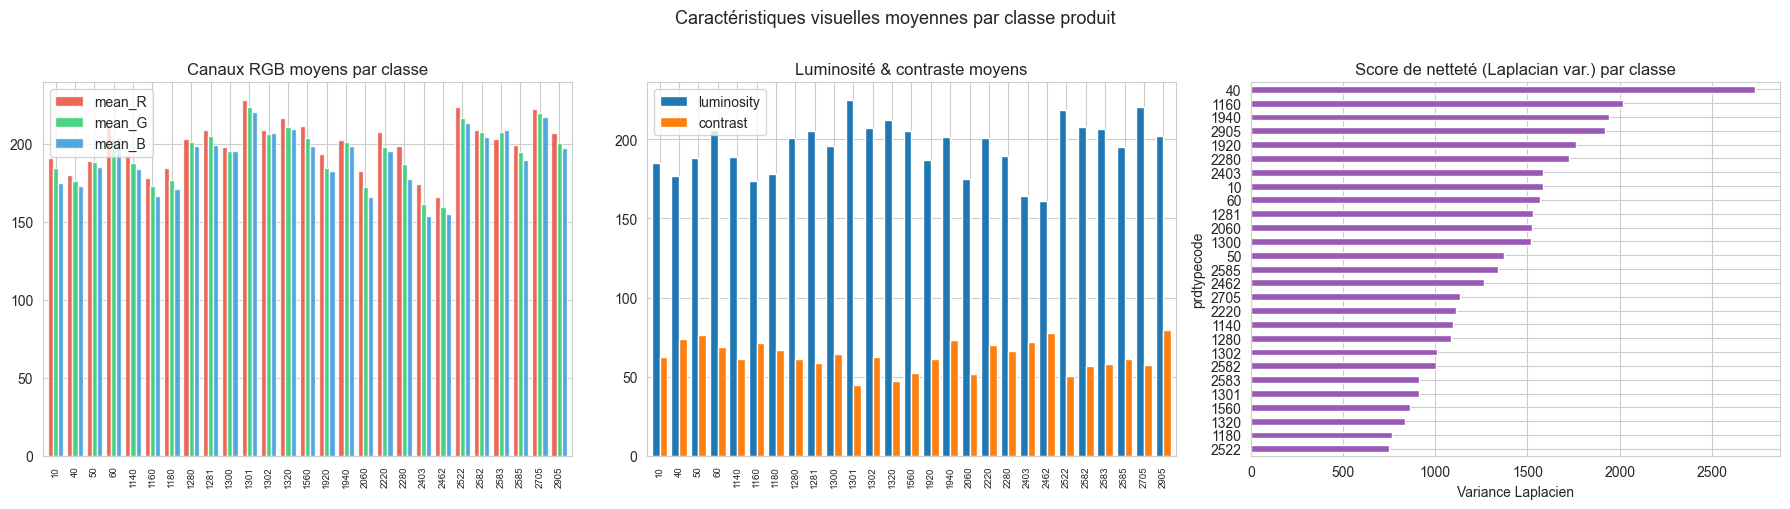

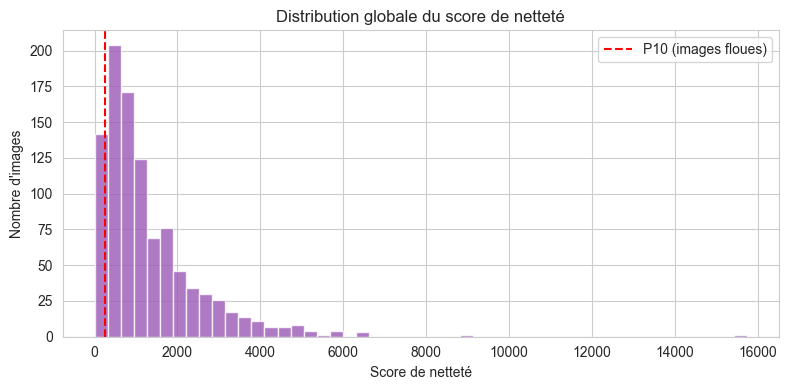

Images en-dessous du P10 de netteté (<255.5) : 100 (10.0%)


In [51]:
# Visualisation : couleurs & netteté par classe
if len(df_img) > 0:
    img_profile = df_img.groupby(target_col)[
        ["mean_R", "mean_G", "mean_B", "luminosity", "contrast", "sharpness"]
    ].mean().round(1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Canaux RGB moyens par classe
    img_profile[["mean_R", "mean_G", "mean_B"]].plot(
        kind="bar", ax=axes[0], color=["#e74c3c", "#2ecc71", "#3498db"],
        width=0.8, alpha=0.85)
    axes[0].set_title("Canaux RGB moyens par classe"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", labelsize=7)

    # Luminosité + contraste
    img_profile[["luminosity", "contrast"]].plot(kind="bar", ax=axes[1], width=0.8)
    axes[1].set_title("Luminosité & contraste moyens"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", labelsize=7)

    # Score de netteté
    img_profile["sharpness"].sort_values().plot(kind="barh", ax=axes[2], color="#9b59b6")
    axes[2].set_title("Score de netteté (Laplacian var.) par classe"); axes[2].set_xlabel("Variance Laplacien")

    plt.suptitle("Caractéristiques visuelles moyennes par classe produit", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # Distribution de la netteté globale
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df_img["sharpness"], bins=50, color="#9b59b6", edgecolor="white", alpha=0.8)
    ax.axvline(df_img["sharpness"].quantile(0.10), color="red", linestyle="--", label="P10 (images floues)")
    ax.set_xlabel("Score de netteté"); ax.set_ylabel("Nombre d'images")
    ax.set_title("Distribution globale du score de netteté")
    ax.legend(); plt.tight_layout(); plt.show()
    blur_threshold = df_img["sharpness"].quantile(0.10)
    print(f"Images en-dessous du P10 de netteté (<{blur_threshold:.1f}) : "
          f"{(df_img['sharpness'] < blur_threshold).sum()} ({(df_img['sharpness'] < blur_threshold).mean()*100:.1f}%)")


Ces résultats montre que certaines images sont plus nettes que d'autre, confirmant ainsi l'utilisation de facteur de description de l'image autre que la taille (heigth, width) pour enrichir la description de l'image.

### 14.3 Analyse d'alignement texte-image

**Objectif :** identifier les produits pour lesquels **l'image est la seule source d'information fiable**.

- Produits sans description **ET** avec désignation courte → reposent entièrement sur l'image
- Cross-tabulation : `has_description` × classe × langue dominante
- Distribution de la "richesse textuelle" par classe (score composite)


In [52]:
#  Score de richesse textuelle 
df_align = df_train[[target_col, "designation_length", "description_length",
                      "has_description"]].copy()

# Score composite normalisé [0, 1]
max_desig = df_align["designation_length"].quantile(0.95) + 1e-9
max_desc  = df_align["description_length"].quantile(0.95)  + 1e-9

df_align["text_richness"] = (
    0.4 * (df_align["designation_length"] / max_desig).clip(0, 1) +
    0.6 * (df_align["description_length"]  / max_desc ).clip(0, 1)
)

# Produits "image-only" : pas de description ET désignation courte (< médiane)
desig_median = df_align["designation_length"].median()
mask_image_only = (df_align["has_description"] == 0) & (df_align["designation_length"] < desig_median)
df_align["image_only"] = mask_image_only.astype(int)

print(f"Produits 'image-only' (pas de description + désignation courte) : "
      f"{mask_image_only.sum()} ({mask_image_only.mean()*100:.1f}%)")
print()

# Distribution par classe
image_only_rate = df_align.groupby(target_col)["image_only"].mean().sort_values(ascending=False)
print("Top 10 classes avec le plus de produits 'image-only' :")
display(image_only_rate.head(10).rename("taux_image_only").to_frame())


Produits 'image-only' (pas de description + désignation courte) : 20068 (23.6%)

Top 10 classes avec le plus de produits 'image-only' :


,taux_image_only
prdtypecode,
2462,0.680507
1160,0.668100
10,0.638318
1180,0.632199
2403,0.602011
40,0.601675
1140,0.499064
2705,0.340094
2280,0.333824


`taux_image_only` : Confirme l'hypothèse que certaine classe dépendent plus de la présence d'une image et ceux malgrès une designation + description

#### Pourcentage de deqscription en fonction de la langue (avec ou sans texte)

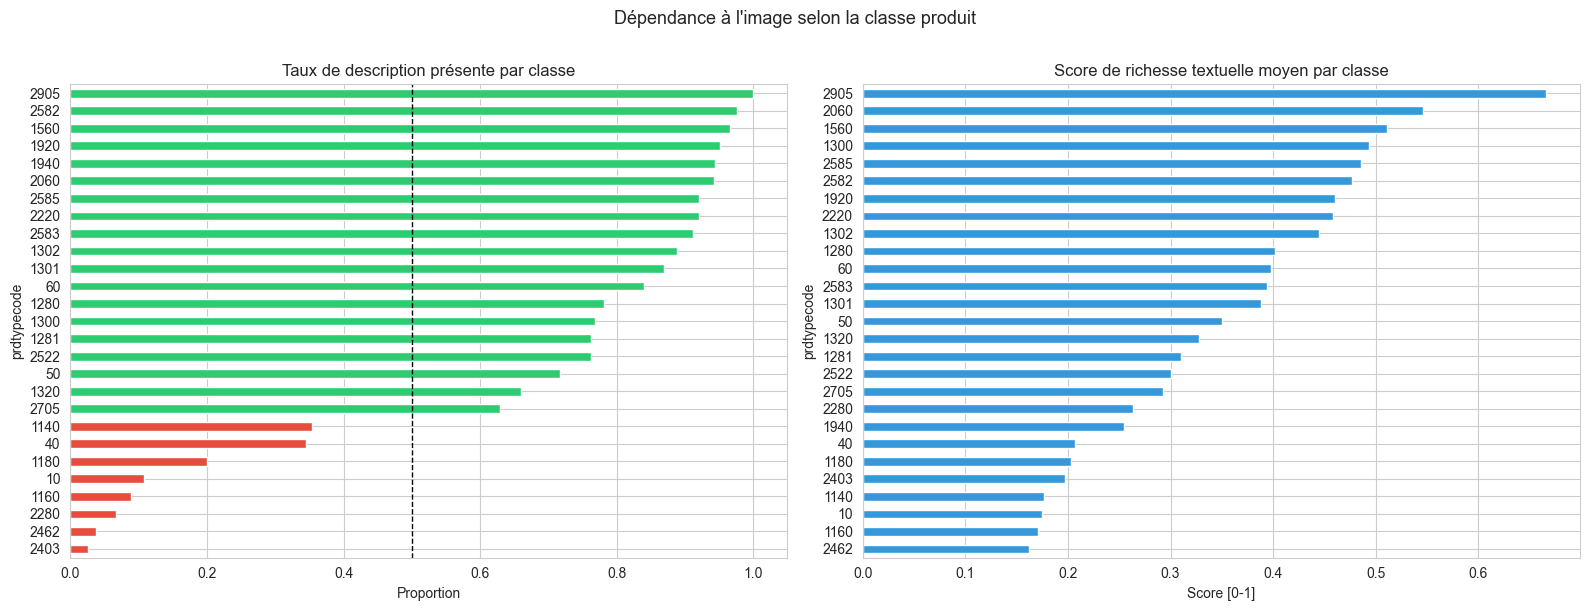


Taux de description par langue :


,sans_desc,avec_desc
lang,,
fr,0.295,0.705
ca,0.392,0.608
en,0.407,0.593
ro,0.421,0.579
pt,0.437,0.563
it,0.455,0.545
sk,0.467,0.533
de,0.478,0.522
nl,0.488,0.512


In [53]:
# Cross-tabulation : has_description × classe
xtab = pd.crosstab(df_train[target_col], df_train["has_description"],
                   normalize="index").rename(columns={0: "sans_desc", 1: "avec_desc"})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taux de description par classe (trié)
xtab["avec_desc"].sort_values().plot(kind="barh", ax=axes[0],
    color=["#e74c3c" if v < 0.5 else "#2ecc71" for v in xtab["avec_desc"].sort_values()])
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Taux de description présente par classe")
axes[0].set_xlabel("Proportion")

# Score de richesse textuelle par classe
richness_by_class = df_align.groupby(target_col)["text_richness"].mean().sort_values()
richness_by_class.plot(kind="barh", ax=axes[1], color="#3498db")
axes[1].set_title("Score de richesse textuelle moyen par classe")
axes[1].set_xlabel("Score [0-1]")

plt.suptitle("Dépendance à l'image selon la classe produit", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# Cross-tab langue × has_description (si langue disponible)
if "lang" in df_train.columns:
    xtab_lang = pd.crosstab(df_train["lang"], df_train["has_description"], normalize="index")
    xtab_lang.columns = ["sans_desc", "avec_desc"]
    print("\nTaux de description par langue :")
    display(xtab_lang.sort_values("avec_desc", ascending=False).round(3))


#### Fearture additionnelle pour caractériser la description avec la langue

-  `sans_desc` 
-  `avec_desc`

<br>

### 14.4 Analyse des classes minoritaires

**Objectif :** comprendre pourquoi certaines classes sont très petites  
et anticiper les difficultés de classification.

- Profil détaillé des 5 classes les plus petites vs les 5 plus grandes
- Vérifier si les petites classes souffrent d'un déficit textuel ou linguistique
- Visualisation de la distribution de longueur de texte par taille de classe


In [54]:
# Classes minoritaires vs majoritaires
class_counts = df_train[target_col].value_counts()
n_minority = 5

minority_classes = class_counts.tail(n_minority).index.tolist()
majority_classes = class_counts.head(n_minority).index.tolist()

df_train["class_group"] = "other"
df_train.loc[df_train[target_col].isin(minority_classes), "class_group"] = "minority (bottom 5)"
df_train.loc[df_train[target_col].isin(majority_classes), "class_group"] = "majority (top 5)"

print("\n 5 classes les PLUS PETITES")
minority_profile = df_train[df_train[target_col].isin(minority_classes)].groupby(target_col).agg(
    n_obs            = ("designation", "count"),
    pct_has_desc     = ("has_description", "mean"),
    desig_len_mean   = ("designation_length", "mean"),
    desc_len_mean    = ("description_length", "mean"),
).round(2)
if "lang" in df_train.columns:
    minority_profile["lang_dom"] = (df_train[df_train[target_col].isin(minority_classes)]
                                     .groupby(target_col)["lang"].agg(dominant_lang))
display(minority_profile.sort_values("n_obs"))

print("\n 5 classes les PLUS GRANDES ")
majority_profile = df_train[df_train[target_col].isin(majority_classes)].groupby(target_col).agg(
    n_obs            = ("designation", "count"),
    pct_has_desc     = ("has_description", "mean"),
    desig_len_mean   = ("designation_length", "mean"),
    desc_len_mean    = ("description_length", "mean"),
).round(2)
if "lang" in df_train.columns:
    majority_profile["lang_dom"] = (df_train[df_train[target_col].isin(majority_classes)]
                                     .groupby(target_col)["lang"].agg(dominant_lang))
display(majority_profile.sort_values("n_obs", ascending=False))



 5 classes les PLUS PETITES


,n_obs,pct_has_desc,desig_len_mean,desc_len_mean,lang_dom
prdtypecode,,,,,
1180,764,0.20,51.98,143.74,en
1940,803,0.94,50.46,317.81,fr
1301,807,0.87,74.62,507.12,fr
2220,824,0.92,75.35,749.87,fr
60,832,0.84,108.17,251.79,fr



 5 classes les PLUS GRANDES 


,n_obs,pct_has_desc,desig_len_mean,desc_len_mean,lang_dom
prdtypecode,,,,,
2583,10209,0.91,57.56,718.85,fr
1560,5073,0.97,83.28,922.25,fr
1300,5045,0.77,92.03,765.40,fr
2060,4993,0.94,85.84,1012.44,fr
2522,4989,0.76,72.89,260.33,fr


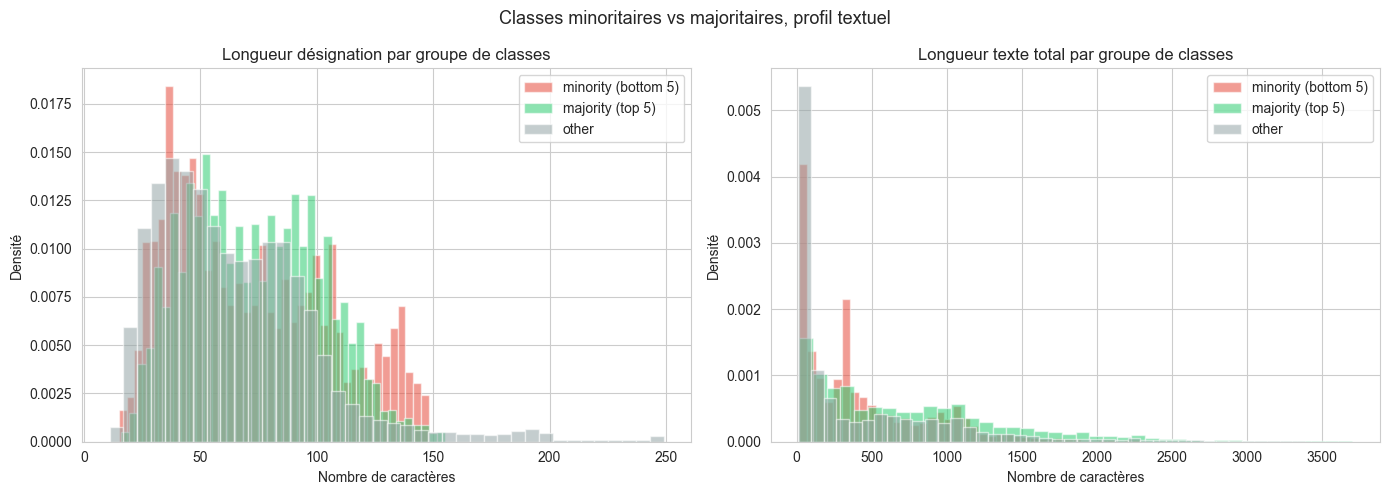

In [55]:
# Visualisation : distribution des longueurs par groupe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
    ["designation_length", "text_total_length"],
    ["Longueur désignation", "Longueur texte total"]):

    for group, color in [("minority (bottom 5)", "#e74c3c"),
                          ("majority (top 5)",    "#2ecc71"),
                          ("other",               "#95a5a6")]:
        data = df_train.loc[df_train["class_group"] == group, col].dropna()
        data = data[data < data.quantile(0.99)]   # enlever outliers extrêmes
        ax.hist(data, bins=40, alpha=0.55, label=group, color=color, density=True)
    ax.set_title(f"{title} par groupe de classes")
    ax.set_xlabel("Nombre de caractères"); ax.set_ylabel("Densité")
    ax.legend()

plt.suptitle("Classes minoritaires vs majoritaires, profil textuel", fontsize=13)
plt.tight_layout(); plt.show()

# Nettoyage colonne temporaire
df_train.drop(columns=["class_group"], inplace=True, errors="ignore")


### 14.5 N-grammes & quasi-doublons (Levenshtein)

**Objectif :** affiner l'analyse du vocabulaire (au-delà des unigrammes)  
et quantifier la proportion de désignations quasi-identiques qui ne sont pas détectées comme exactement dupliquées.

- **Bigrammes / trigrammes** les plus fréquents par classe → patterns séquentiels discriminants
- **Quasi-doublons** : désignations avec distance de Levenshtein ≤ 5 (fautes de frappe, variantes mineures)


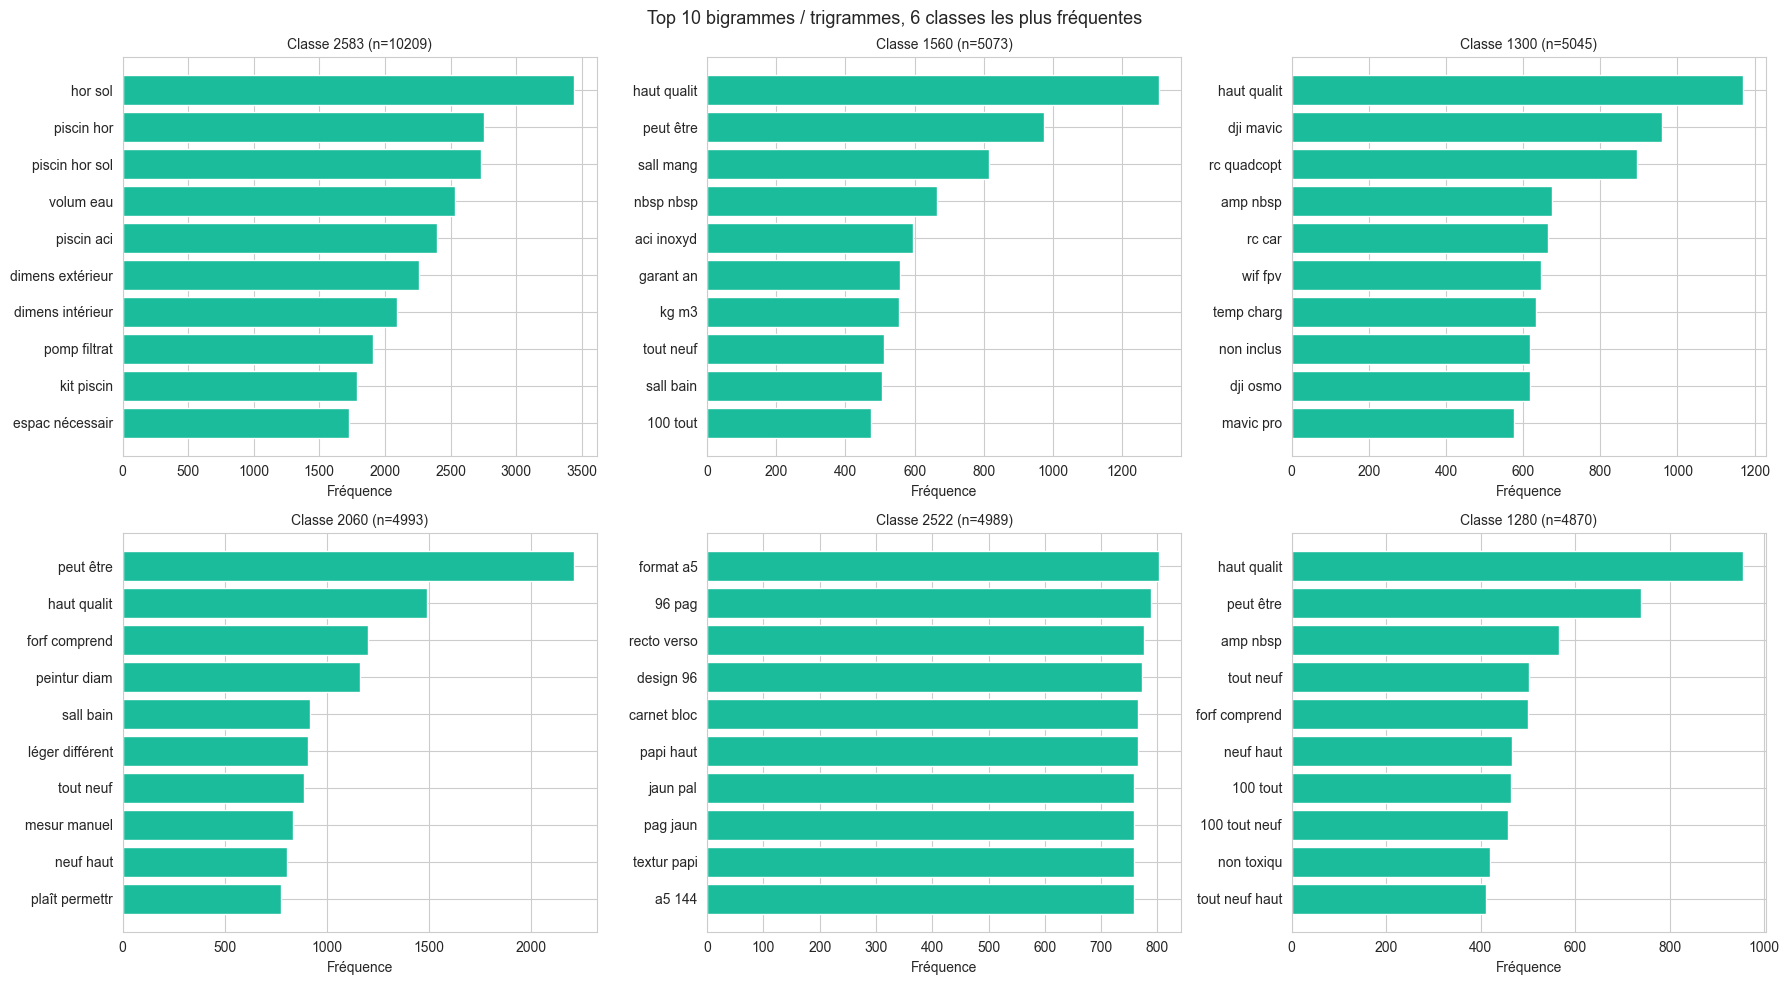

In [56]:
# Top bigrammes & trigrammes par classe
from sklearn.feature_extraction.text import CountVectorizer

corpus_col_clean = "text_concat" if "text_concat" in df_train.columns else "designation_clean"
N_TOP_NGRAMS = 10
CLASSES_SHOW = class_counts.head(6).index.tolist()   # 6 classes les plus fréquentes

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, cls in zip(axes, CLASSES_SHOW):
    corpus_cls = df_train.loc[df_train[target_col] == cls, corpus_col_clean].fillna("")
    cv_ng = CountVectorizer(ngram_range=(2, 3), max_features=500, min_df=2)
    X_ng  = cv_ng.fit_transform(corpus_cls)
    counts = np.asarray(X_ng.sum(axis=0)).flatten()
    vocab_ng = cv_ng.get_feature_names_out()
    top_idx  = counts.argsort()[-N_TOP_NGRAMS:][::-1]
    ax.barh(vocab_ng[top_idx][::-1], counts[top_idx][::-1], color="#1abc9c")
    ax.set_title(f"Classe {cls} (n={len(corpus_cls)})", fontsize=10)
    ax.set_xlabel("Fréquence")

plt.suptitle(f"Top {N_TOP_NGRAMS} bigrammes / trigrammes, 6 classes les plus fréquentes", fontsize=13)
plt.tight_layout(); plt.show()


In [57]:
# Identifier les quasi-doublons (Levenshtein)

try:
    from rapidfuzz.distance import Levenshtein as lev_dist
    def edit_dist(a, b): return lev_dist.distance(a, b)
    print("Bibliothèque : rapidfuzz")
except ImportError:
    try:
        import jellyfish
        def edit_dist(a, b): return jellyfish.levenshtein_distance(a, b)
        print("Bibliothèque : jellyfish")
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rapidfuzz"])
        from rapidfuzz.distance import Levenshtein as lev_dist
        def edit_dist(a, b): return lev_dist.distance(a, b)
        print("Bibliothèque : rapidfuzz (installée)")

MAX_EDIT_DIST = 5     # seuil de quasi-doublon
SAMPLE_SIZE   = 1000  # limite pour garder le calcul O(n²) raisonnable

# Échantillon des désignations uniques (version brute, avant nettoyage)
desig_unique = df_train["designation"].dropna().unique()
rng2 = np.random.default_rng(42)
desig_sample = rng2.choice(desig_unique, size=min(SAMPLE_SIZE, len(desig_unique)), replace=False)

# Calcul des paires quasi-dupliquées
quasi_pairs = []
for i in range(len(desig_sample)):
    for j in range(i + 1, len(desig_sample)):
        d = edit_dist(desig_sample[i], desig_sample[j])
        if d <= MAX_EDIT_DIST:
            quasi_pairs.append((desig_sample[i], desig_sample[j], d))

print(f"Paires quasi-dupliquées (distance ≤ {MAX_EDIT_DIST}) "
      f"dans l'échantillon de {len(desig_sample)} désignations : {len(quasi_pairs)}")

if quasi_pairs:
    df_quasi = pd.DataFrame(quasi_pairs, columns=["desig_A", "desig_B", "edit_distance"])
    print(f"Taux estimé : {len(quasi_pairs) / (len(desig_sample)*(len(desig_sample)-1)/2)*100:.2f}% des paires")
    print("\nExemples :")
    display(df_quasi.sort_values("edit_distance").head(10))


Bibliothèque : rapidfuzz (installée)
Paires quasi-dupliquées (distance ≤ 5) dans l'échantillon de 1000 désignations : 1
Taux estimé : 0.00% des paires

Exemples :


,desig_A,desig_B,edit_distance
0,Tuyau 32 mm 3m Pour Pompe De Filtration,Tuyau 38 mm 3m Pour Pompe De Filtration,1


### Quasi doublons

Il y a bien la présence du texte qui se ressemble. Une étape supplémentaire dans l'analyse consisterai à supprimer les quasi doublons du jeu de donnée

### Synthèse des analyses supplémentaire pour enrichir l'EAD (14.1 → 14.7)

| # | Enrichissement | Valeur principale |
|---|---|---|
| 14.1 | Profils par classe | Distinguer les classes text-dependent vs image-dependent |
| 14.2 | Analyse visuelle | Détecter les images floues/sombres, caractériser chaque classe visuellement |
| 14.3 | Alignement texte-image | Quantifier les produits reposant uniquement sur l'image |
| 14.4 | Classes minoritaires | Anticiper les difficultés sur les petites classes |
| 14.5 | N-grammes + quasi-doublons | Révéler des patterns séquentiels, estimer la redondance textuelle |

### Synthèse des analyses supplémentaire pour enrichir l'EAD (14.1 → 14.5)

| Nouvelle features | Desc |
|---|---|
| desig_len_mean  | Longueur moyenne de la designation |
| desc_len_mean | Longueur moyenne de la  diffidesignation |
| text_total_len_mean| longeur moyenne textuelle (description + designation) |
| Sharpness | netteté de l'image |
| Constrast | Contraste de l'image |
| Luminosité | luminosité de l'image |
| avec_desc | Caractéristique de la description en fonction de la langue |
| sans_desc | Caractéristique du manque de description en fonction de la langue |
